# Прогнозирование повторной госпитализации пациента

## Задание 1. Подготовка и анализ данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_object_dtype
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score, recall_score, accuracy_score, precision_score, confusion_matrix, roc_auc_score, roc_curve
import shap

In [2]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

### 1. Считывае данных и первичный обзор

In [3]:
df = pd.read_csv('diabetic_data.csv', encoding='utf8', sep=',')
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.shape

(101766, 50)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
print(f'Список всех колонок: {df.columns.to_list()}')

Список всех колонок: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [8]:
numeric_column = []
object_column = []

for column in df:
    if is_object_dtype(df[column].dtype):
        object_column.append(column)
    else:
        numeric_column.append(column)
    
print('-'*60)
print(f'Категориальные признаки: \n{object_column} \nКоличество столбцов:{len(object_column)}')
print('-'*60)
print(f'Количественные признаки: \n{numeric_column} \nКоличество столбцов:{len(numeric_column)}')
print('-'*60)

------------------------------------------------------------
Категориальные признаки: 
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed'] 
Количество столбцов:36
------------------------------------------------------------
Количественные признаки: 
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses

In [9]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### 2. Преобразование целевой переменной

In [4]:
readmitted_map = {'NO': 0, '>30': 0, '<30': 1}
df['readmitted'] = df['readmitted'].map(readmitted_map)

### 3. Анализ баланса классов, дубликатов и пропусков.

#### 3.1. Дубликаты строк:

In [11]:
duplicates_id = df.duplicated(subset=['encounter_id'])
duplicates_nbr = df.duplicated(subset=['patient_nbr'])
l1, l2 = 0, 0
for str in duplicates_id:
    if str == True:
        l1 += 1
print(f'Количество дубликатов по encounter_id: {l1}')

Количество дубликатов по encounter_id: 0


#### 3.2. Баланс классов:

In [12]:
df['readmitted'].value_counts(normalize=True)

readmitted
0    0.888401
1    0.111599
Name: proportion, dtype: float64

В 8 раз перевес класса 0 (повторной госпитализации в течение 30 дней не происходило).

#### 3.3. Пропуски категориальных признаков:

In [5]:
df = df.replace(['?', 'Unknown/Invalid', 'nan'], np.nan)
print('Столбцы с пропусками:')
for column in df:
    if df[column].isnull().sum() != 0:
        print(column, df[column].isnull().sum())

Столбцы с пропусками:
race 2273
gender 3
weight 98569
payer_code 40256
medical_specialty 49949
diag_1 21
diag_2 358
diag_3 1423
max_glu_serum 96420
A1Cresult 84748


In [9]:
one_value = []
str_nan = {}
print('-'*80)
uniq = []
for i in range(len(object_column)):
    print(f'**Название столбца: {object_column[i]}')
    print(f'Количество уникальных значений: {len(df[object_column[i]].unique())}')
    if len(df[object_column[i]].unique()) == 1:
        one_value.append(object_column[i])
    print(df[object_column[i]].unique())
    str = df.loc[df[object_column[i]].isna()].index.tolist()
    print(df[object_column[i]].value_counts())
    print(f'Количество пропусков:{len(str)}')
    print('-'*80)
    if len(str) != 0:
        str_nan[object_column[i]] = len(str)
    

--------------------------------------------------------------------------------
**Название столбца: race
Количество уникальных значений: 6
['Caucasian' 'AfricanAmerican' nan 'Other' 'Asian' 'Hispanic']
race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
Количество пропусков:2273
--------------------------------------------------------------------------------
**Название столбца: gender
Количество уникальных значений: 3
['Female' 'Male' nan]
gender
Female    54708
Male      47055
Name: count, dtype: int64
Количество пропусков:3
--------------------------------------------------------------------------------
**Название столбца: age
Количество уникальных значений: 10
['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)

In [16]:
print('Только одно значение во всем столбце')
print(one_value)

Только одно значение во всем столбце
['examide', 'citoglipton']


In [17]:
print('Столбцы с пропусками:')
print(str_nan)

Столбцы с пропусками:
{'race': 2273, 'gender': 3, 'weight': 98569, 'payer_code': 40256, 'medical_specialty': 49949, 'diag_1': 21, 'diag_2': 358, 'diag_3': 1423, 'max_glu_serum': 96420, 'A1Cresult': 84748}


#### 3.4. Пропуски количественнных признаков

In [18]:
one_value2 = []
str_nan2 = {}
print('-'*80)
for i in range(len(numeric_column)):
    print(f'**Название столбца: {numeric_column[i]}')
    print(f'Количество уникальных значений: {len(df[numeric_column[i]].unique())}')
    if len(df[numeric_column[i]].unique()) == 1:
        one_value2.append(numeric_column[i])
    print(df[numeric_column[i]].unique())
    str = df.loc[df[numeric_column[i]].isna()].index.tolist()
    print(f'Количество пропусков:{len(str)}')
    print('-'*80)
    if len(str) != 0:
        str_nan2[numeric_column[i]] = len(str)

--------------------------------------------------------------------------------
**Название столбца: encounter_id
Количество уникальных значений: 101766
[  2278392    149190     64410 ... 443854148 443857166 443867222]
Количество пропусков:0
--------------------------------------------------------------------------------
**Название столбца: patient_nbr
Количество уникальных значений: 71518
[  8222157  55629189  86047875 ... 140199494 120975314 175429310]
Количество пропусков:0
--------------------------------------------------------------------------------
**Название столбца: admission_type_id
Количество уникальных значений: 8
[6 1 2 3 4 5 8 7]
Количество пропусков:0
--------------------------------------------------------------------------------
**Название столбца: discharge_disposition_id
Количество уникальных значений: 26
[25  1  3  6  2  5 11  7 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
Количество пропусков:0
-----------------------------------------------------------

In [19]:
print('Только одно значение во всем столбце')
print(one_value2)

Только одно значение во всем столбце
[]


In [20]:
print('Столбцы с пропусками (количественные):')
print(str_nan2)

Столбцы с пропусками (количественные):
{}


### 4. Распределение количественных признаков по целевой группе

Удаляем 'encounter_id' и 'patient_nbr'. Это уникальные метки для каждой строки. Они не объясняют целевую переменную и не помогают понять распределение других признаков, не несут никакой информации.

In [10]:
numeric_column.remove('encounter_id')
numeric_column.remove('patient_nbr')

In [22]:
print(numeric_column)

['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


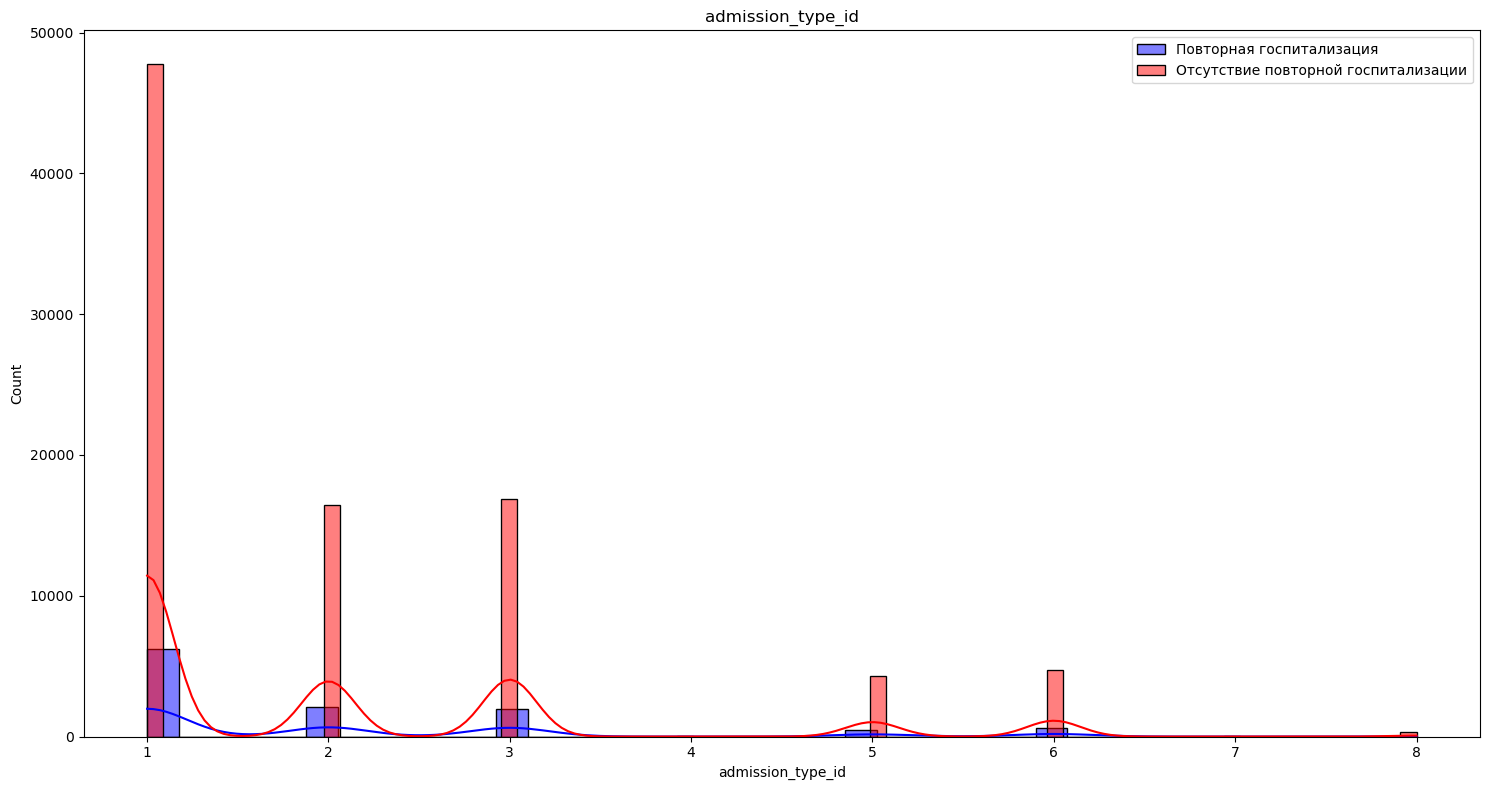

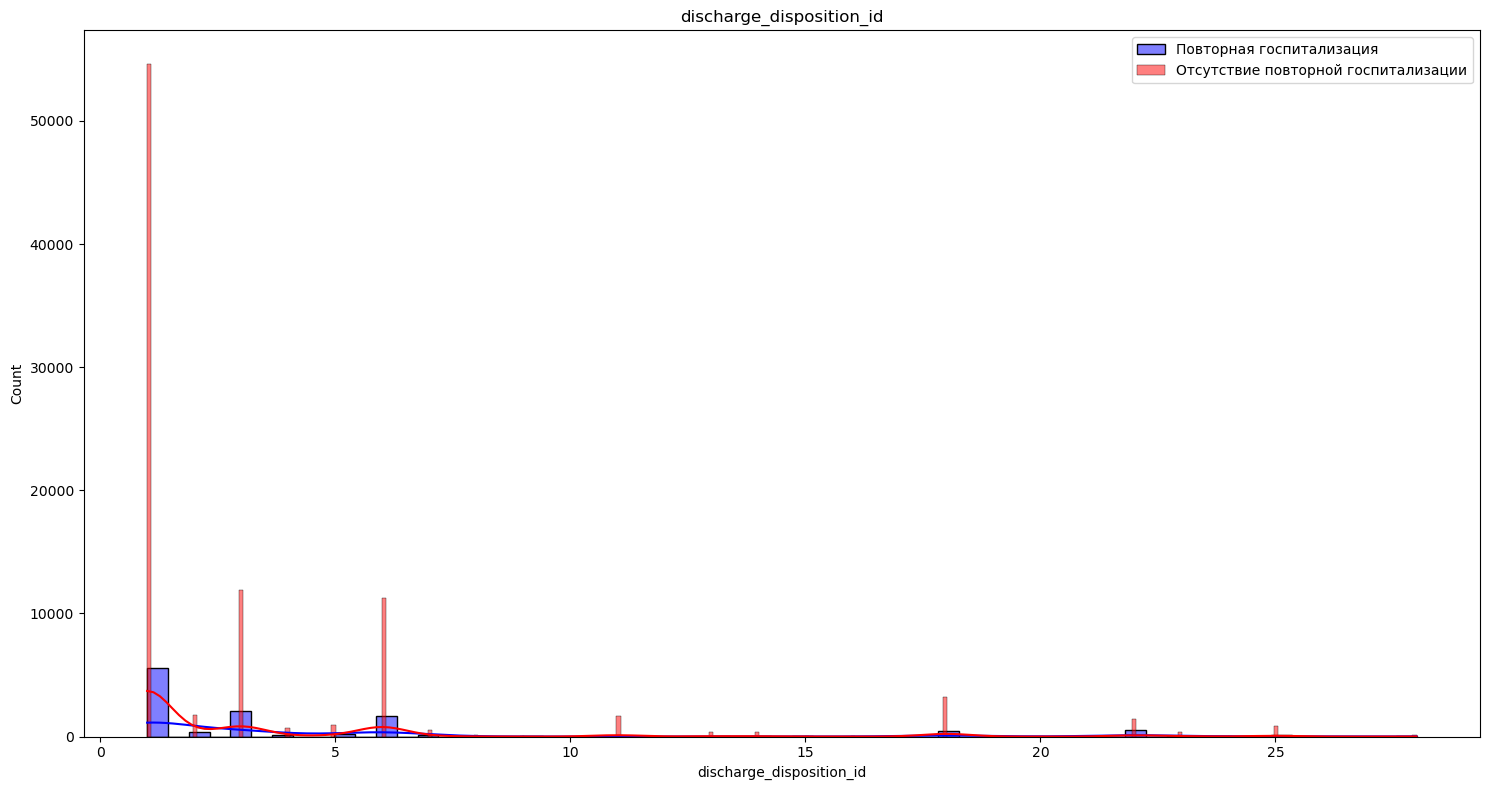

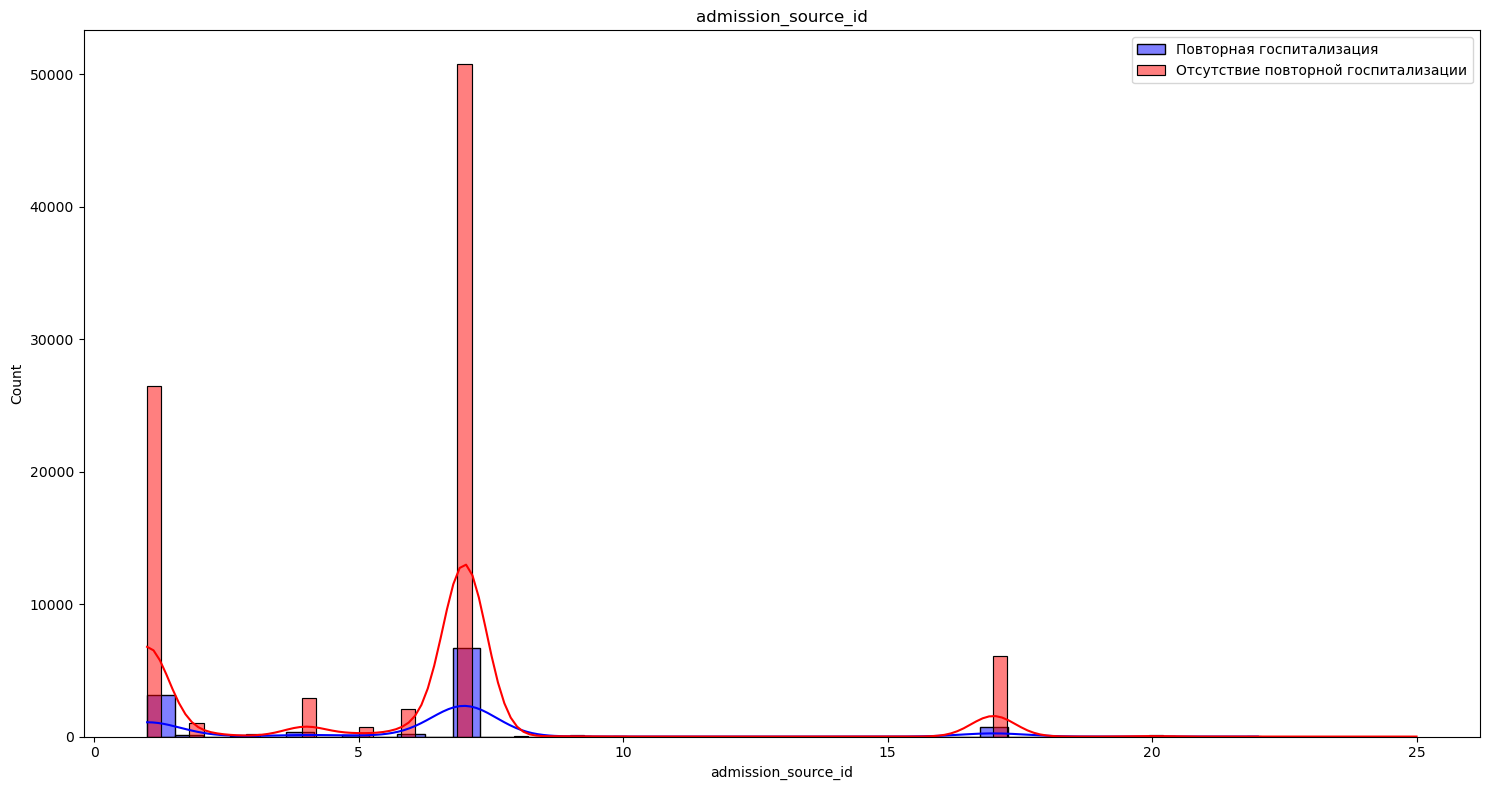

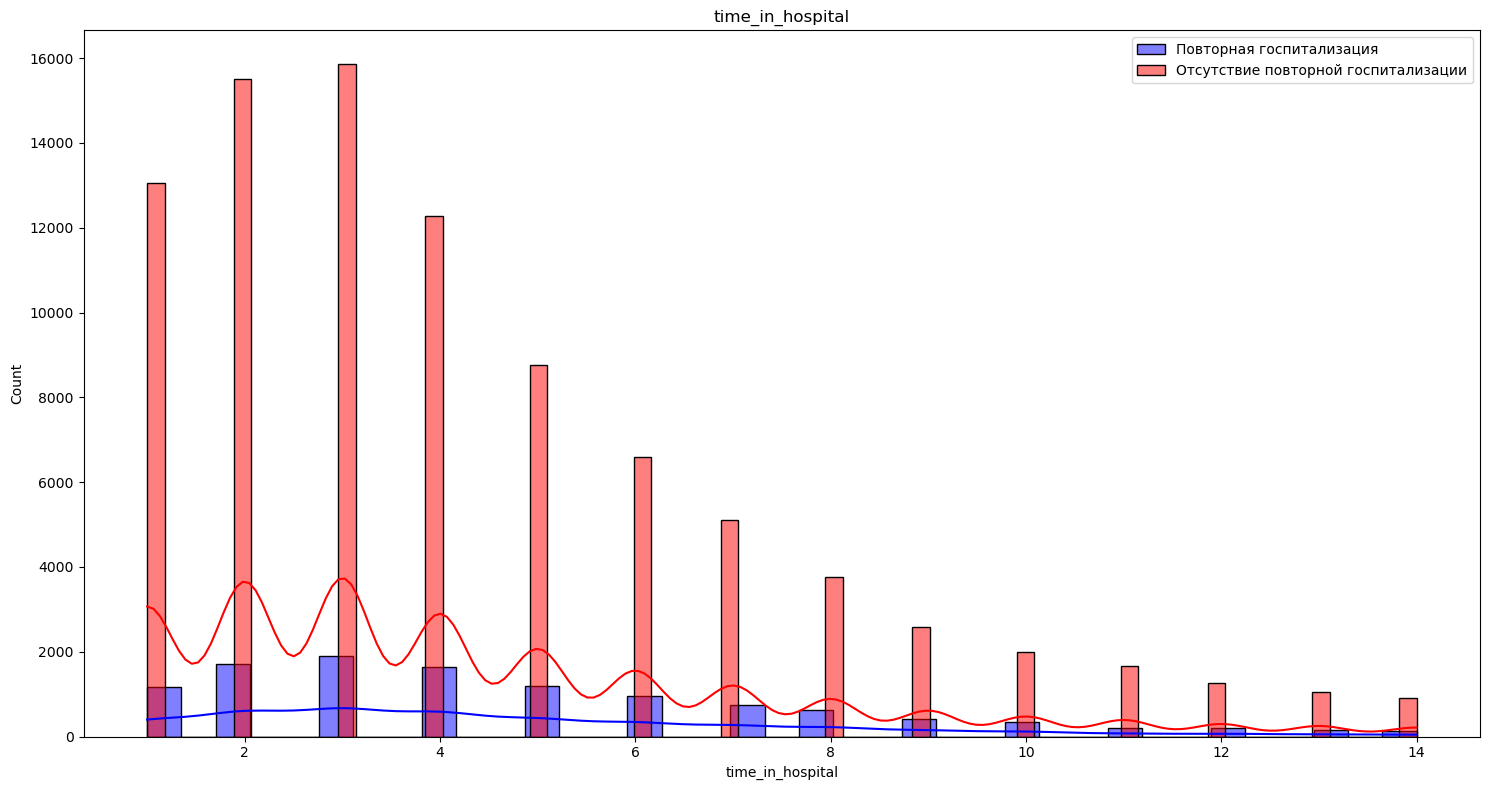

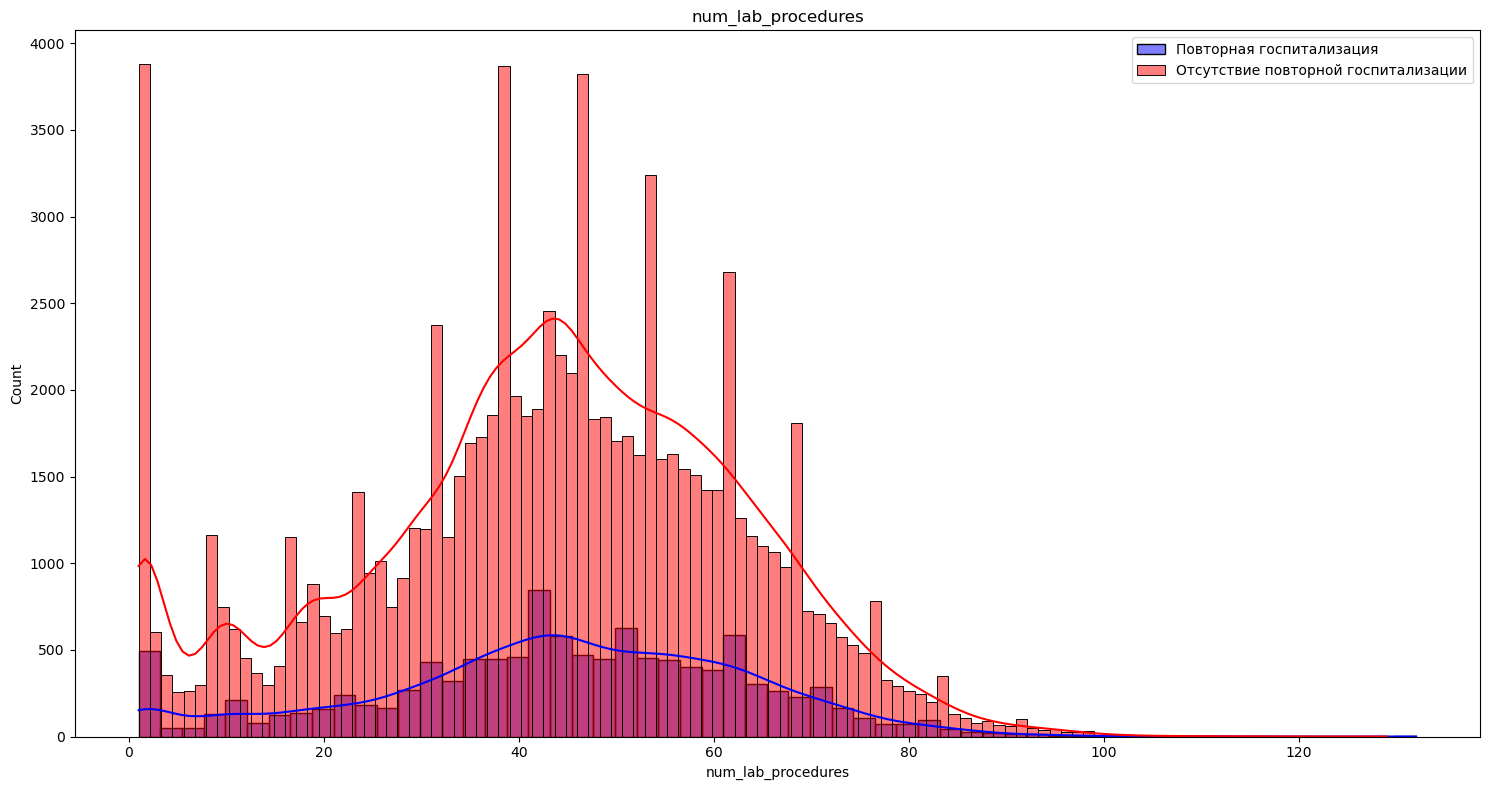

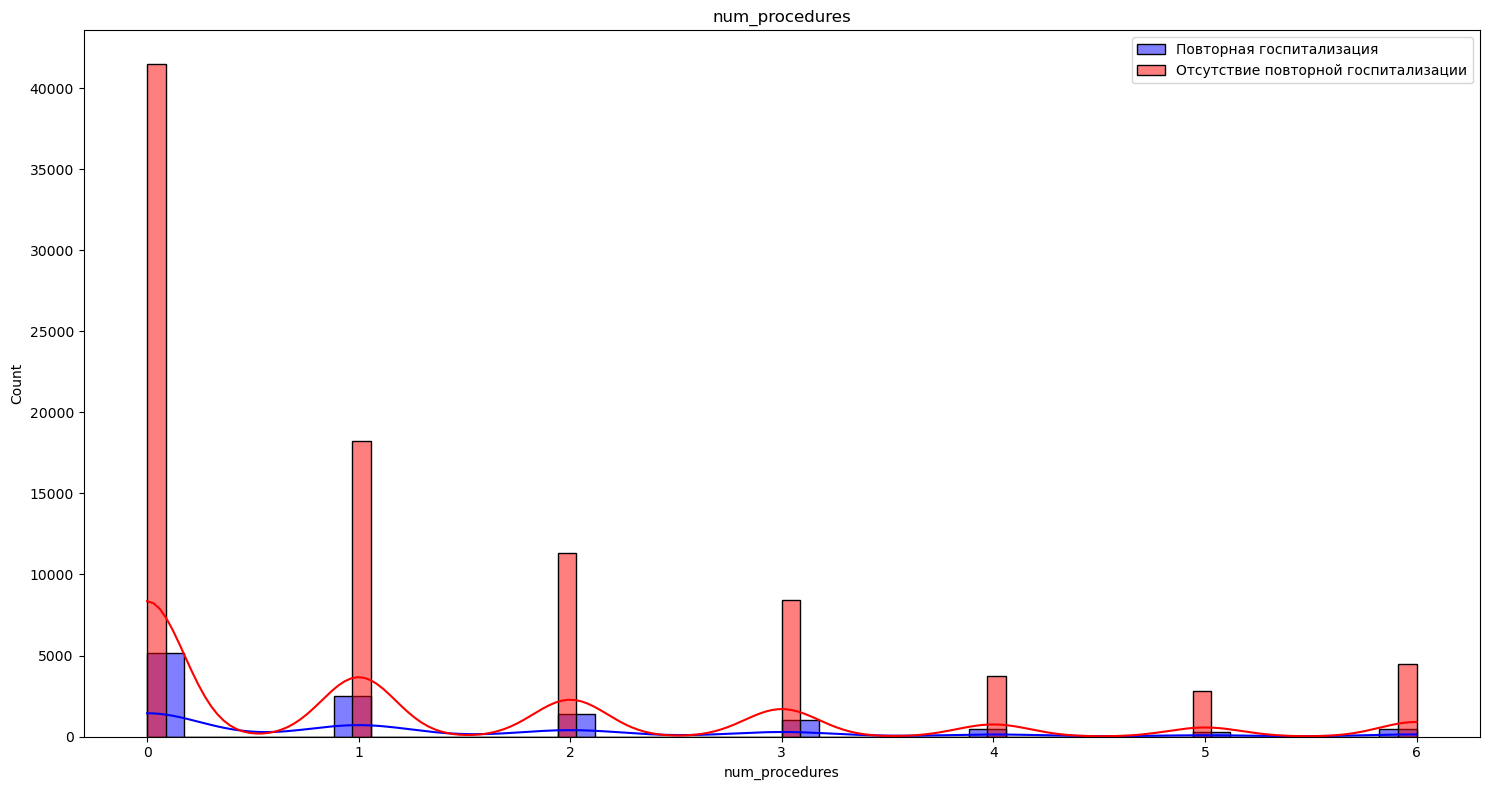

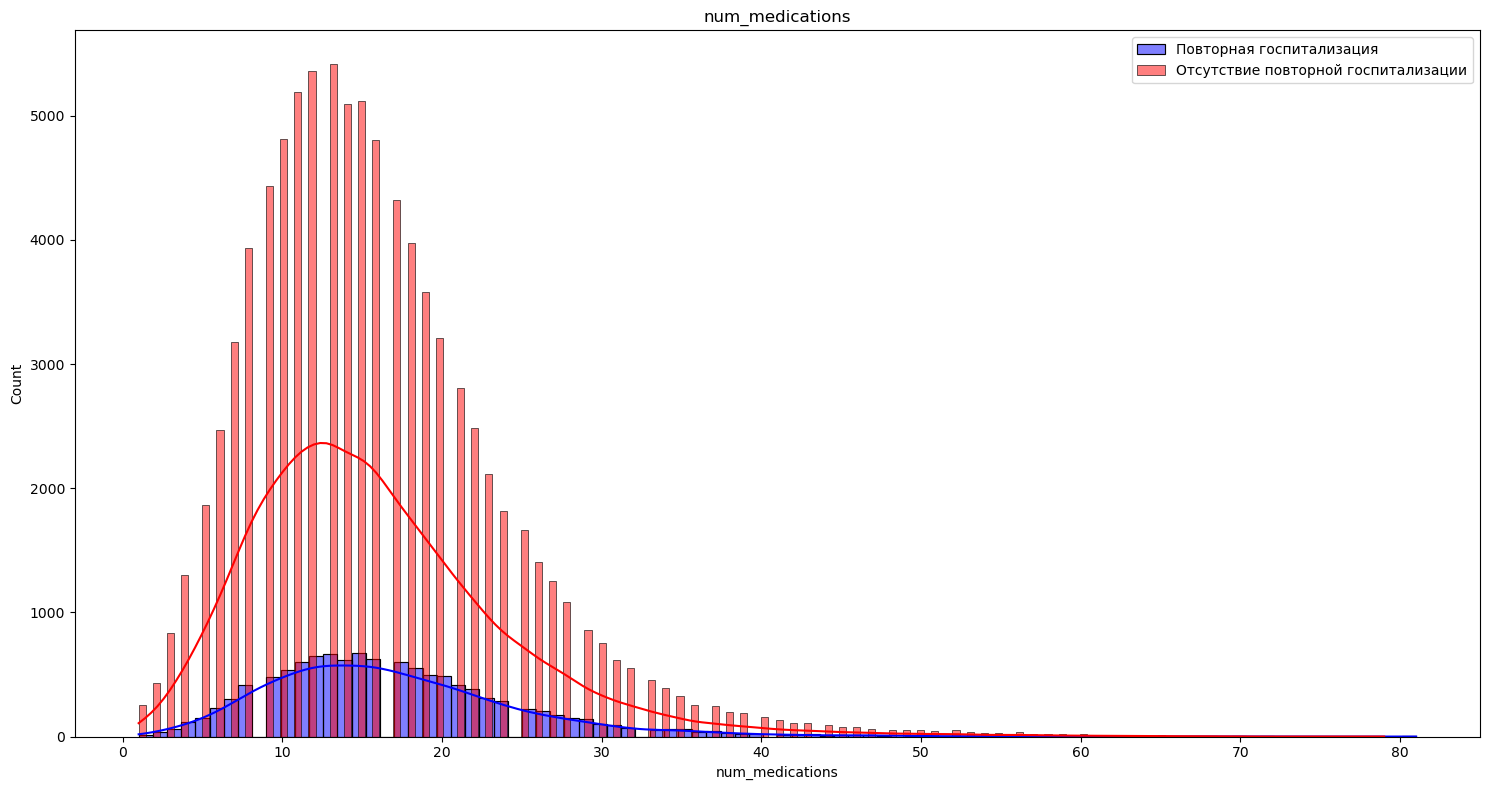

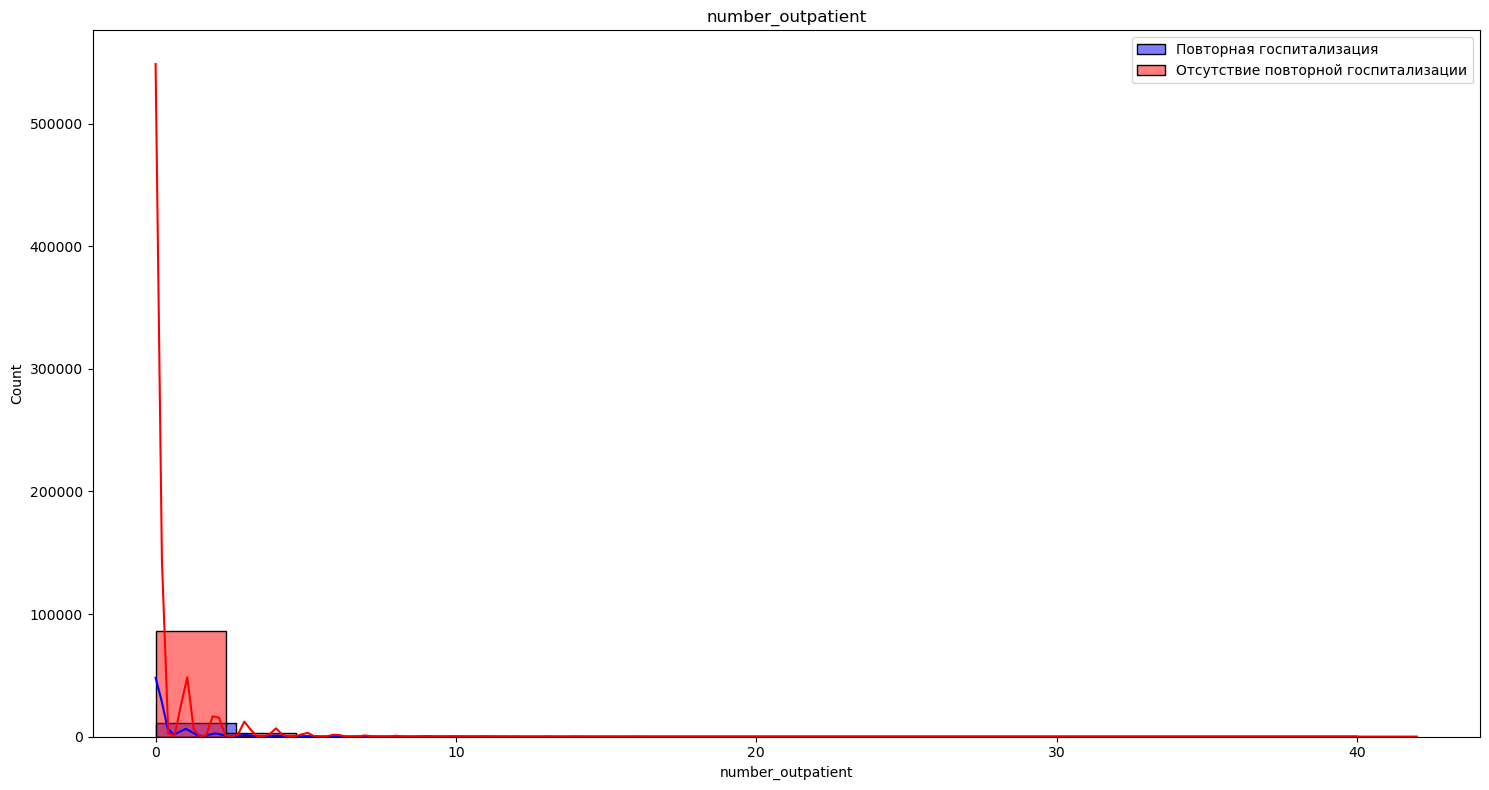

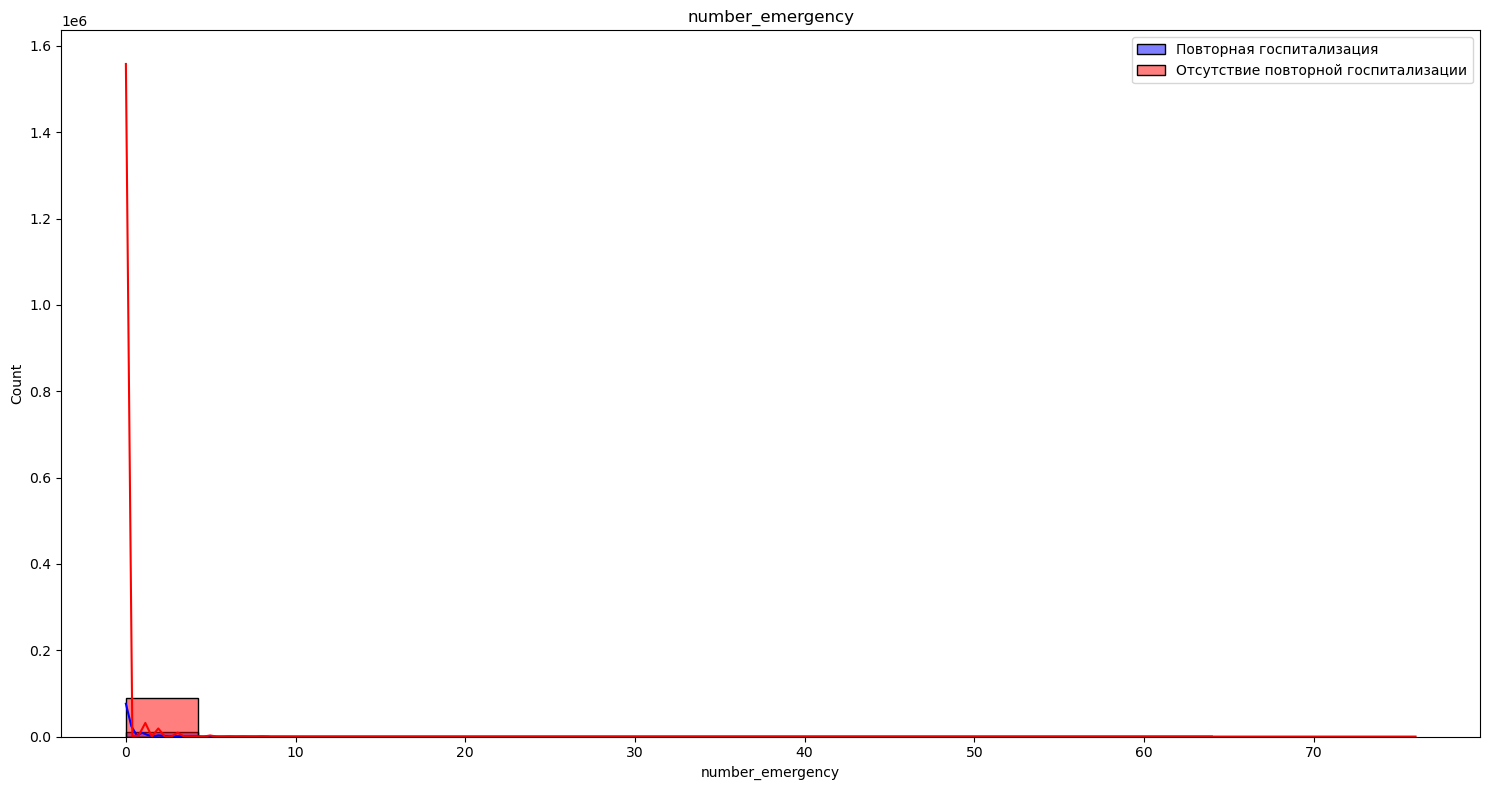

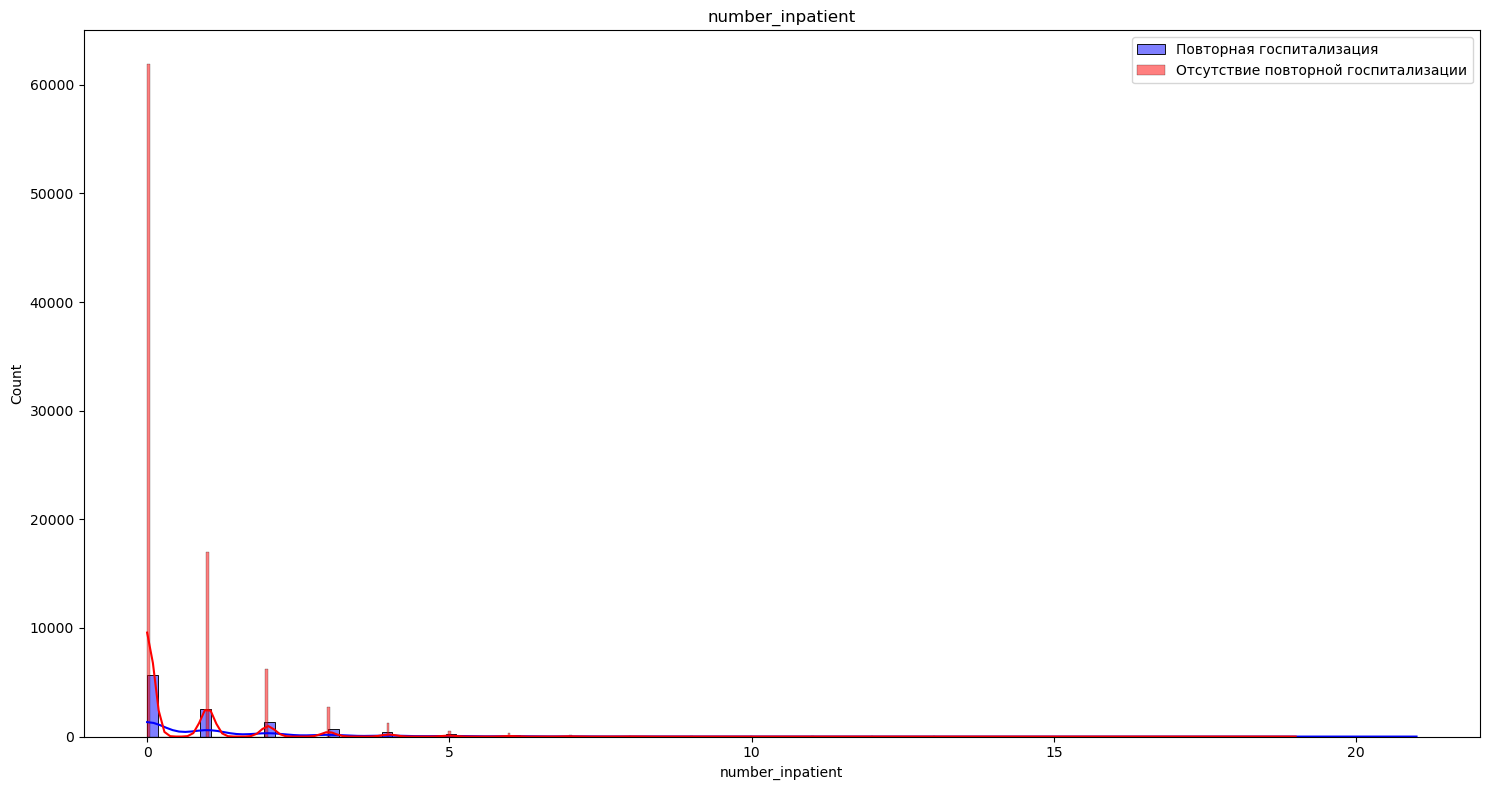

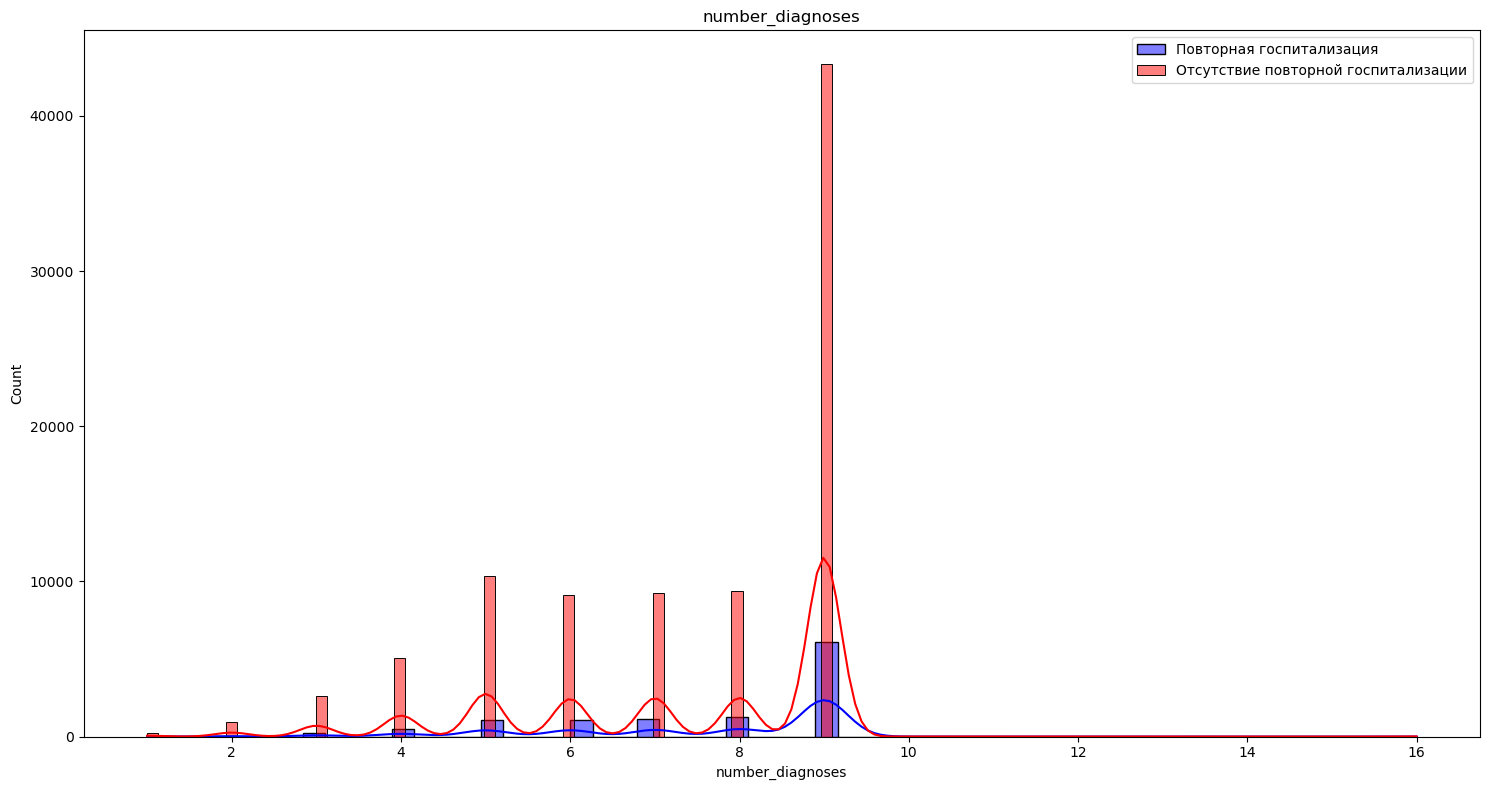

In [23]:
indx = 0
rows_num = 1

for j in range(1,12):
    fig, axes = plt.subplots(1, rows_num, figsize=(15, 8))
    # axes = axes.flatten()
    for i in range(rows_num):
        if indx >= len(numeric_column):
            break
        sns.histplot(
            data = df[df['readmitted'] == 1],
            x = numeric_column[indx],
            color = 'blue',
            label = 'Повторная госпитализация',
            alpha = 0.5,
            kde = True,
            # ax=axes[i]
        )
        sns.histplot(
            data = df[df['readmitted'] == 0],
            x = numeric_column[indx],
            color = 'red',
            label = 'Отсутствие повторной госпитализации',
            alpha = 0.5,
            kde = True,
            # ax=axes[i]
        )
        # axes[i].set_title(numeric_column[indx])
        # axes[i].legend()
        plt.title(numeric_column[indx])
        plt.legend()
        indx += 1
    plt.tight_layout()
    plt.show()

Основной вывод: хотя число повторных госпитализаций меньше общего числа пациентов, пропорционально синие и красные столбцы в целом повторяют друг друга. Это может говорить о том, что данные признаки, возможно, не является сильными предикторами повторной госпитализации

#### 5. Удаление ненужных столбцов  

Для начала оценим важность препаратов, далее просмотрев количество пропусков, оценим, нужно ли оставлять или нет

| Препарат | Назначение / действие | Важность |
|-----------|------------------------|-----------|
| Metformin | Снижает выработку глюкозы, повышает чувствительность к инсулину | 4 |
| Insulin | Заместительная гормональная терапия при диабете | 4 |
| Glimepiride | Стимулирует секрецию инсулина (современная сульфонилмочевина) | 3 |
| Glipizide | Стимулирует выработку инсулина | 3 |
| Glyburide | Аналог glipizide, стимулирует поджелудочную | 3 |
| Pioglitazone | Повышает чувствительность тканей к инсулину | 3 |
| Repaglinide | Быстродействующий стимулятор инсулина (перед едой) | 2 |
| Nateglinide | Аналог repaglinide, короткое действие | 2 |
| Rosiglitazone | Повышает чувствительность к инсулину, ограничен по применению | 2 |
| Acarbose | Замедляет всасывание углеводов в кишечнике | 2 |
| Miglitol | Аналог acarbose | 2 |
| Glyburide-Metformin | Комбинированная терапия (стимулятор + сенситайзер) | 2 |
| Glipizide-Metformin | Комбинация аналогичного действия | 2 |
| Metformin-Pioglitazone | Комбинация сенситайзеров | 2 |
| Metformin-Rosiglitazone | Комбинация, ограниченное применение | 2 |
| Chlorpropamide | Старый стимулятор инсулина | 1 |
| Tolbutamide | Старое поколение сульфонилмочевин | 1 |
| Tolazamide | Устаревший препарат | 1 |
| Acetohexamide | Старый препарат сульфонилмочевины | 1 |
| Troglitazone | Снят с рынка (токсичен) | 1 |
| Examide | Не используется в клинике | 1 |
| Citoglipton | Отсутствует в практике | 1 |
| Glimepiride-Pioglitazone | Комбинация, не имеет преимуществ | 1 |


Удаляем следующие столбцы:
* 'encounter_id', 'patient_nbr' - id посещений и пациентов
* 'weight' - почти 97% пропусков(+ не несет в себе особо важной информации)
* 'examide','citoglipton','metformin-pioglitazone', 'metformin-rosiglitazone', 'glimepiride-pioglitazone', 'glipizide-metformin', 'troglitazone', 'acetohexamide', 'tolazamide', 'miglitol', 'tolbutamide', 'chlorpropamide', 'acarbose', 'glyburide-metformin', 'nateglinide' - по важности низкое значение, либо неиспользуемый в клинике, либо по балансу значений не подходит(очень много пропусков - неизветных значений).

In [11]:
df.drop(['weight', 'examide', 'citoglipton','metformin-pioglitazone',
          'metformin-rosiglitazone', 'glimepiride-pioglitazone', 'glipizide-metformin',
            'troglitazone', 'tolazamide', 'acetohexamide','miglitol', 'tolbutamide', 'chlorpropamide',
              'acarbose', 'glyburide-metformin', 'nateglinide','encounter_id', 'patient_nbr'  
              ], axis=1, inplace=True)

In [25]:
df.shape

(101766, 32)

In [26]:
print(f'Список оставшихся колонок: {df.columns.to_list()}')

Список оставшихся колонок: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted']


#### 6. Ответы на вопросы:

#### Вопрос 1: клинически значимые признаки  
В общем заболевания классифицируются по следующим принципам: характер заболевания(хроническое, острое заболевание), основная локализация болезни(система крови, органов дыхания, сердца и тд), по патогенезу(аутоимунное, аллергическое и тд), по этиологии(генетическое, инфекционное и тд), возраст пациента,  основной принцип лечения(хиругическое вмешательство, терапевтическое лечение), по полу. Отталкиваясь от этих принципов можно классифициовать болезни и понять как тяжело лечится болезнь, может ли быть рецидив, как долго восстанавливается пациент.
    
Признаки, которые прямо или косвенно связаны с этими принципами: 'age', 'gender', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses','medical_specialty', 'change', 'diabetesMed', 'number_emergency' + все препараты и значение анализов  
    
Также влияет правильная постановка диагноза и правильное лечение(косвенно влияет социальный статус, возможно не всем по цене доступны дорогие препараты). Таким образом важными признаками могут оказаться: 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_inpatient'  
    
Количественные признаки по предварительным графикам не являются сильными предикторами  
  
#### Вопрос 2: перекосы в распределении 
Правосторонний перекос: 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'. Левосторонней перекос: 'number_diagnoses'.  
   
Признаки 'admission_type_id', 'discharge_disposition_id', 'admission_source_id' скорее являются категориальными, нежели числовыми, возможно стоит их преобразовать.
Признаки 'number_outpatient', 'number_emergency', 'number_inpatient'. Создать бинарный признак: было ли предыдущее посещение.  
    
Для 'time_in_hospital, 'num_procedures', 'num_medications' можно попробовать сделать логарифмирование.  
     
Перекос не всегда нужно исправлять, он может нести важную информацию для модели, стоит потестировать в разных модификациях.
   
#### Вопрос 3: дисбаланс классов 
Данные имеют сильный дисбаланс классов в целевой переменной. В данном случае разница в 8 раз. Я бы в первую очередь попробовала комбинирование андерсемплинга и оверсемплинга (например SMOTE + Tomek Links/Edited Nearest Neighbors). Поскольку медицинские данные очень сложны и вероятнее всего отдельный метод может оказаться неэффективным, при недостатке андерсемплинга потеря информации, при недостатке оверсемплинга переобучение и шум. Нам нужно увеличить количество редких примеров (SMOTE) и одновременно удалить шум, возникающий в результате перекрытия классов(Tomek Links: удаляет пары ближайших образцов, принадлежащих к разным классам).

## Задание 2. Инженерия признаков 

### 2.1. Обработка пропусков

In [27]:
del str_nan['weight']
print('Категориальные столбцы с пропусками:')
print(str_nan)

Категориальные столбцы с пропусками:
{'race': 2273, 'gender': 3, 'payer_code': 40256, 'medical_specialty': 49949, 'diag_1': 21, 'diag_2': 358, 'diag_3': 1423, 'max_glu_serum': 96420, 'A1Cresult': 84748}


#### Столбец "race"  

Для начала пропущенные значения поменяем на новую группу. После чего посмотрим распределение по целевой переменной.

In [12]:
df['race'] = df['race'].fillna('Missing')
df_missing_race = df[df['race'] == 'Missing']
df_other = df[df['race'] == 'Other']

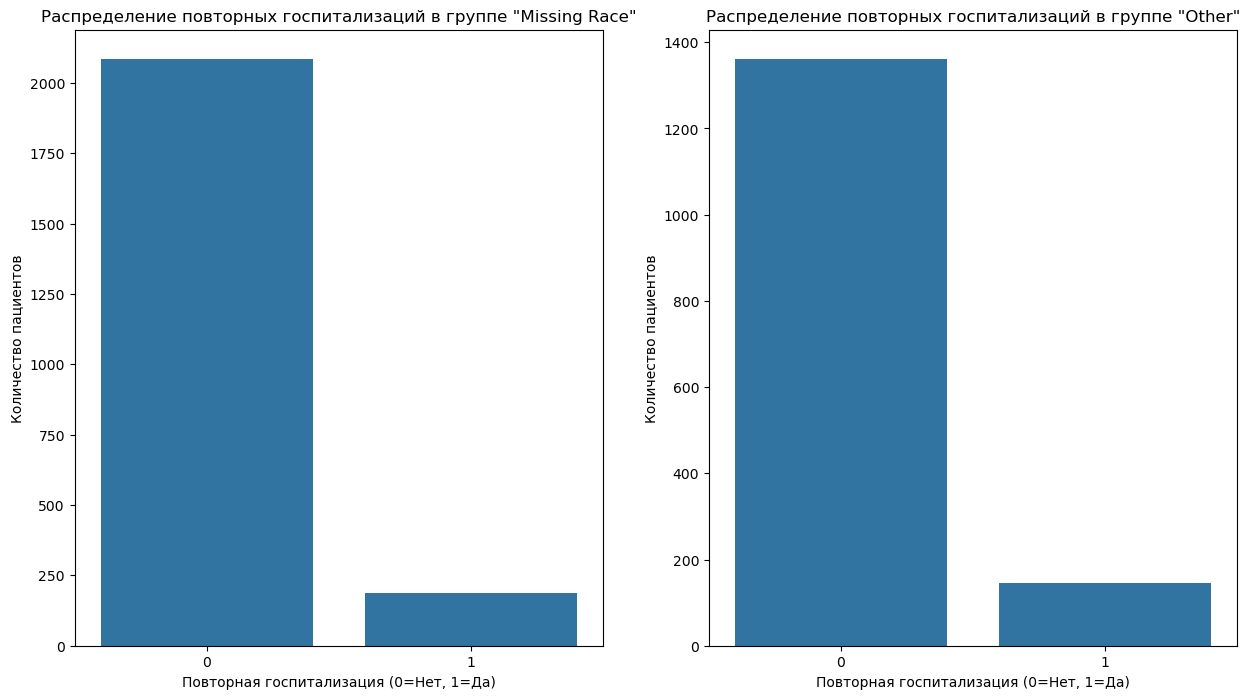

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

sns.countplot(
    data=df_missing_race,
    x='readmitted',
    ax=axes[0]
)

axes[0].set_title('Распределение повторных госпитализаций в группе "Missing Race"')
axes[0].set_xlabel('Повторная госпитализация (0=Нет, 1=Да)')
axes[0].set_ylabel('Количество пациентов')

sns.countplot(
    data=df_other,
    x='readmitted',
    ax=axes[1]
)

axes[1].set_title('Распределение повторных госпитализаций в группе "Other"')
axes[1].set_xlabel('Повторная госпитализация (0=Нет, 1=Да)')
axes[1].set_ylabel('Количество пациентов')
plt.show()

Качественно графики очень похожи, следовательно мы можем объеденить всё в одну категорию "other".

In [14]:
df = df.replace(['Missing'], 'Other')
df['race'].unique()

array(['Caucasian', 'AfricanAmerican', 'Other', 'Asian', 'Hispanic'],
      dtype=object)

#### Столбцы 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult'

Для столбцов, где около половины и более пропусков, но которые содержат важную информацию, пропуски определим в отдельную категорию.

In [15]:
df['payer_code'] = df['payer_code'].fillna('Unknown')
df['medical_specialty'] = df['medical_specialty'].fillna('GeneralPractitioner')
df['max_glu_serum'] = df['max_glu_serum'].fillna('Unknown')
df['A1Cresult'] = df['A1Cresult'].fillna('Unknown')

#### Столбцы 'diag_1', 'diag_2', 'diag_3'

Присутствуют пропуски по диагнозам. Это может быть важной информацией, возможно диагноз не удалось установить. Заменим в этих столбцах все пропуски на 10000 (условно обозначаем отдельную группу, записываем цифрами, чтобы потом обрабатывать числовые значения)

In [16]:
df['diag_1'] = df['diag_1'].fillna('10000')
df['diag_2'] = df['diag_2'].fillna('10000')
df['diag_3'] = df['diag_3'].fillna('10000')

#### Столбец 'gender'

Если он относится к доминирующему классу 0, то можно удалить, поскольку к тому же 3 пропуска. Пол является номинальным категориальным признаком, который сложно надежно импутировать (заменить пропуск).

In [17]:
columns_to_show = ['age', 'diag_1', 'diag_2', 'diag_3', 
                   'diabetesMed', 'number_diagnoses', 
                   'max_glu_serum', 'A1Cresult', 'readmitted']

mask_nan_gender = df['gender'].isna()

df_nan_gender = df[mask_nan_gender][columns_to_show]

print(df_nan_gender)

           age diag_1 diag_2 diag_3 diabetesMed  number_diagnoses  \
30506  [70-80)    414    411    401         Yes                 4   
75551  [60-70)    808    873   E813          No                 5   
82573  [70-80)    850    805    808         Yes                 9   

      max_glu_serum A1Cresult  readmitted  
30506       Unknown   Unknown           0  
75551       Unknown   Unknown           0  
82573       Unknown   Unknown           0  


In [18]:
df.dropna(subset=['gender'], inplace = True)
df = df.reset_index(drop=True) # пересоздаем индексы

#### Проверим пропуски:

In [19]:
for column in df:
    if df[column].isnull().sum() != 0:
        print(column, df[column].isnull().sum())

Для хорошей модели необходимо правильно преобразовать категориальные признаки.  
  
Чтобы это сделать нужно понять, какую информацию мы можем достать из столбца и насколько она важна. Например у нас есть столбец медицинская специальность, в которой 79 значений, которые в свою очередь надо сгруппировать. Есть значение 'кардиохирургия', но куда его отнести, к кардиологам или к хирургам? Кардиология классифицирует болезнь, а хирургия указывает на вид лечения. Поскольку у нас есть ещё столбик с диагнозом, то если отнести к кардиологии, то это будет повтор информации, а из столбика специальность мы можем достать новую информацию о виде лечения.

Таким образом первое предположение о кодирование

| Признак             | Уникальные значения | Кодирование                                                                                   |
|----------------------|---------------------|-----------------------------------------------------------------------------------------------|
| race                 | 5                   | one-hot                                                                                       |
| gender               | 2                   | бинарное                                                                                      |
| age                  | -                   | числовой признак                                                                              |
| payer_code           | 17                  | группировка по организации/финансовому состоянию → порядковое кодирование                     |
| medical_specialty    | 73                  | группировка по виду лечения → one-hot                                                         |
| diag_1               | 717                 | группировка по области → one-hot                                                              |
| diag_2               | -                   | аналогично diag_1 → one-hot                                                                   |
| diag_3               | -                   | аналогично diag_1 → one-hot                                                                   |
| max_glu_serum        | 4                   | кодирование с порядком                                                                        |
| A1Cresult            | 4                   | кодирование с порядком                                                                        |
| metformin            | 4                   | кодирование с порядком                                                                        |
| repaglinide          | 4                   | кодирование с порядком                                                                        |
| glimepiride          | 4                   | кодирование с порядком                                                                        |
| glipizide            | 4                   | кодирование с порядком                                                                        |
| glyburide            | 4                   | кодирование с порядком                                                                        |
| pioglitazone         | 4                   | кодирование с порядком                                                                        |
| rosiglitazone        | 4                   | кодирование с порядком                                                                        |
| insulin              | 4                   | кодирование с порядком                                                                        |
| change               | 2                   | бинарное                                                                                      |
| diabetesMed          | 2                   | бинарное                                                                                      |


### 2.2. One-hot кодирование категориальных признаков и/или группировка редких категорий
### +
### 2.5. Кодировка клинической направленности диагнозов

In [20]:
numeric_column = []
object_column = []

for column in df:
    if is_object_dtype(df[column].dtype):
        object_column.append(column)
    else:
        numeric_column.append(column)
    
print('-'*60)
print(f'Категориальные признаки: \n{object_column} \nКоличество столбцов:{len(object_column)}')
print('-'*60)
print(f'Количественные признаки: \n{numeric_column} \nКоличество столбцов:{len(numeric_column)}')
print('-'*60)

------------------------------------------------------------
Категориальные признаки: 
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed'] 
Количество столбцов:20
------------------------------------------------------------
Количественные признаки: 
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmitted'] 
Количество столбцов:12
------------------------------------------------------------


Обработка 'race'

In [21]:
encoder_race = OneHotEncoder(sparse_output=False)
encoded_array = encoder_race.fit_transform(df[['race']])
encoded_df = pd.DataFrame(encoded_array, columns=encoder_race.get_feature_names_out(['race']))

df = pd.concat([df.drop(columns=['race']), encoded_df], axis=1)

Обработка 'diag_1', 'diag_2', 'diag_3'

In [22]:
def diabetes(icd):
    try:
        return str(icd).startswith("250")
    except:
        return False

def hypertension(icd):
    try:
        code = float(icd)
        return 401 <= code <= 405
    except:
        return False

def infection(icd):
    try:
        code = float(icd)
        return 1 <= code <= 139
    except:
        return False

df['diabetes_flag'] = df[['diag_1','diag_2','diag_3']].apply(
    lambda x: any(diabetes(i) for i in x), axis=1
).astype(int)

df['hypertension_flag'] = df[['diag_1','diag_2','diag_3']].apply(
    lambda x: any(hypertension(i) for i in x), axis=1
).astype(int)

df['infection_flag'] = df[['diag_1','diag_2','diag_3']].apply(
    lambda x: any(infection(i) for i in x), axis=1
).astype(int)


In [23]:
del str
def chronic(icd):
    if pd.isna(icd):
        return 0
    try:
        code = float(str(icd))
    except ValueError:
        return 0
    if 240 <= code <= 279:
        return 1
    elif 390 <= code <= 459:
        return 1
    elif 490 <= code <= 496:
        return 1
    elif 290 <= code <= 319:
        return 1
    elif 330 <= code <= 349:
        return 1
    elif 580 <= code <= 629:
        return 1
    elif 710 <= code <= 739:
        return 1
    elif 140 <= code <= 239:
        return 1

    else:
        return 0

df['n_chronic_conditions'] = df[['diag_1', 'diag_2', 'diag_3']].apply(
    lambda x: sum(chronic(i) for i in x), axis=1
)

Для начала заменим E и V (внешние причины травм и дополнительная классификация) на числовые значения, далее сгруппируем диагнозы по мкб-9.

In [24]:
cols = ['diag_1', 'diag_2', 'diag_3']

for i in cols:
    df.loc[df[i].str.contains('E'),i] = '1000'
    df.loc[df[i].str.contains('V'),i] = '1001'

df = df.astype({'diag_1': float, 'diag_2': float, 'diag_3': float})

In [25]:
df['diag_1'].dtypes 

dtype('float64')

In [26]:
for i in cols:

    df[i] = df[i].astype('string')

    numeric = pd.to_numeric(df[i], errors='coerce')

    df.loc[(1 <= numeric) & (numeric <= 139), i] = 'Infectious'
    df.loc[(140 <= numeric) & (numeric <= 239), i] = 'Neoplasms'
    df.loc[(240 <= numeric) & (numeric <= 279), i] = 'Endocrine/metabolic'
    df.loc[(280 <= numeric) & (numeric <= 289), i] = 'Blood disorders'
    df.loc[(290 <= numeric) & (numeric <= 319), i] = 'Mental disorders'
    df.loc[(320 <= numeric) & (numeric <= 389), i] = 'Nervous system'
    df.loc[(390 <= numeric) & (numeric <= 459), i] = 'Circulatory system'
    df.loc[(460 <= numeric) & (numeric <= 519), i] = 'Respiratory system'
    df.loc[(520 <= numeric) & (numeric <= 579), i] = 'Digestive system'
    df.loc[(580 <= numeric) & (numeric <= 629), i] = 'Genitourinary system'
    df.loc[(630 <= numeric) & (numeric <= 679), i] = 'Pregnancy'
    df.loc[(680 <= numeric) & (numeric <= 709), i] = 'Skin'
    df.loc[(710 <= numeric) & (numeric <= 739), i] = 'Musculoskeletal'
    df.loc[(740 <= numeric) & (numeric <= 759), i] = 'Congenital anomalies'
    df.loc[(760 <= numeric) & (numeric <= 779), i] = 'Perinatal conditions'
    df.loc[(780 <= numeric) & (numeric <= 799), i] = 'Symptoms/ill-defined'
    df.loc[(800 <= numeric) & (numeric <= 999), i] = 'Injury/poisoning'
    df.loc[numeric == 1000, i] = 'External causes'
    df.loc[numeric == 1001, i] = 'Supplementary'
    df.loc[numeric == 10000, i] = 'Unknown'


In [27]:
diag_cols = ['diag_1', 'diag_2', 'diag_3']

encoder_pipeline = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

encoded_array = encoder_pipeline.fit_transform(df[diag_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder_pipeline.named_steps['onehot'].get_feature_names_out(diag_cols),
    index=df.index
)

df = pd.concat([df.drop(columns=diag_cols), encoded_df], axis=1)

Обработка 'medical_specialty'

In [28]:
def map_specialty_to_group(specialty):

    # if pd.isna(specialty):
    #     return "Unknown"

    s = str(specialty).strip()
    if s.startswith("Surgery") or s in ["Surgeon", "SurgicalSpecialty"]:
        return "Surgery"
    elif "Cardiology" in s:
        return "Cardiology"
    elif "Endocrinology" in s or "Metabolism" in s:
        return "Endocrinology"
    elif "Gastroenterology" in s or "Proctology" in s or "Colon" in s:
        return "Gastroenterology"
    elif "Nephrology" in s:
        return "Nephrology"
    elif "Pulmonology" in s:
        return "Pulmonology"
    elif "Hematology" in s or "Oncology" in s:
        return "Oncology/Hematology"
    elif "Neurology" in s or "Neurophysiology" in s:
        return "Neurology"
    elif "Psychiatry" in s or "Psychology" in s:
        return "Psychiatry/Psychology"
    elif "Gynecology" in s or "Obstetrics" in s or "Perinatology" in s:
        return "Ob/Gyn"
    elif "Dermatology" in s:
        return "Dermatology"
    elif "Orthopedics" in s or "Sports" in s:
        return "Orthopedics/Sports"
    elif "Otolaryngology" in s or "Ophthalmology" in s:
        return "ENT/Ophthalmology"
    elif "Allergy" in s or "Immunology" in s:
        return "Allergy/Immunology"
    elif "Infectious" in s:
        return "InfectiousDiseases"
    elif "Anesthesiology" in s:
        return "Anesthesiology"
    elif "Radiology" in s or "Radiologist" in s or "Pathology" in s:
        return "Radiology/Pathology"
    elif "Rehabilitation" in s:
        return "Rehabilitation"
    elif "Rheumatology" in s:
        return "Rheumatology"
    elif "Dentistry" in s:
        return "Dentistry"
    elif "Podiatry" in s:
        return "Podiatry"
    elif "Speech" in s:
        return "Speech"
    elif any(x in s for x in ["Internal", "Family", "GeneralPractice", "Osteopath", "Hospitalist"]):
        return "InternalMedicine"
    elif s in ["OutreachServices", "DCPTEAM", "Resident", "PhysicianNotFound"]:
        return "Other"
    else:
        return "Other"

In [29]:
# del str

df['specialty_group'] = df['medical_specialty'].apply(map_specialty_to_group)
df['specialty_group'].unique()

array(['Endocrinology', 'Other', 'InternalMedicine', 'Cardiology',
       'Surgery', 'Orthopedics/Sports', 'Gastroenterology', 'Nephrology',
       'Psychiatry/Psychology', 'Pulmonology', 'Ob/Gyn',
       'Oncology/Hematology', 'ENT/Ophthalmology', 'Neurology',
       'Anesthesiology', 'Radiology/Pathology', 'Podiatry',
       'Rehabilitation', 'InfectiousDiseases', 'Rheumatology',
       'Allergy/Immunology', 'Dentistry', 'Dermatology', 'Speech'],
      dtype=object)

In [30]:
df.drop(['medical_specialty'], axis=1, inplace=True)

In [31]:
encoder_specialty = OneHotEncoder(sparse_output=False)
encoded_array = encoder_specialty.fit_transform(df[['specialty_group']])
encoded_df = pd.DataFrame(encoded_array, columns=encoder_specialty.get_feature_names_out(['specialty_group']))

df = pd.concat([df.drop(columns=['specialty_group']), encoded_df], axis=1)

### 2.4. Конвертация диапазонов категорий в числовые группы

In [32]:
age_map = {'[0-10)': 5, '[10-20)': 15, '[20-30)':25, '[30-40)': 35, '[40-50)': 45, '[50-60)': 55, '[60-70)': 65,
 '[70-80)': 75, '[80-90)': 85, '[90-100)' :95 }
df['age'] = df['age'].map(age_map)

In [33]:
df.dropna(subset=['gender'], inplace = True)
drug = ['metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
dosage = ['No', 'Down', 'Steady', 'Up']

encoder_drug = OrdinalEncoder(categories = [dosage]) 

for i in drug:
    df[i] = encoder_drug.fit_transform(df[[i]])


In [34]:
norm1 = ['Unknown', 'Norm', '>200', '>300']
norm2 = ['Unknown', 'Norm', '>7', '>8']

encoder_maxglu = OrdinalEncoder(categories = [norm1])
encoder_a1c = OrdinalEncoder(categories = [norm2])

df['max_glu_serum'] = encoder_maxglu.fit_transform(df[['max_glu_serum']])
df['A1Cresult'] = encoder_a1c.fit_transform(df[['A1Cresult']])

По признаку 'payer_code' можно выделить либо оплачивающую организацию, либо примерный уровень жизни/финансовые возможности пациента. Таким оразом

По организации:
| Категория | Коды | Пример |
|------------|------|--------|
| Государственные | MC, MD, CH, DM, SI, OG | Medicare, Medicaid, CHIP |
| Частные / коммерческие | HM, BC, CM, PO | HMO, Blue Cross |
| Военные | CP | Tricare / Champus |
| Самооплата / прочие | SP, WC, MP, OT, UN, FR | Самооплата, компенсация, неопределённо |  
  
По уровню жизни:
| Уровень жизни | Коды | Пример |
|---------------|------|--------|
| Высокий / средний | HM, BC, CM, PO | Частные страховки, HMO, Blue Cross |
| Средний / низкий | MC, MD, CH, DM, SI, OG | Государственные программы: Medicare, Medicaid, CHIP |
| Специальный | CP | Военные: Tricare / Champus |
| Неопределённый / минимальный доход | SP, WC, MP, OT, UN, FR | Самооплата, компенсации, неопределённо |

In [35]:
group_11 = ['SP', 'WC', 'MP', 'OT', 'UN', 'FR']
group_12 = ['CP']
group_13 = ['HM', 'BC', 'CM', 'PO'] 
group_14 = ['MC', 'MD', 'CH', 'DM', 'SI', 'OG'] 

payer_code_map1 = {}
payer_code_map1['Unknown'] = 1
for code in group_11:
    payer_code_map1[code] = 2
for code in group_12:
    payer_code_map1[code] = 3
for code in group_13:
    payer_code_map1[code] = 4
for code in group_14:
    payer_code_map1[code] = 5

df['payer_code'] = df['payer_code'].map(payer_code_map1)

### 2.6. Создание бинарных признаков: 'gender', 'change', 'diabetesMed'

In [36]:
gender_map = {'Male': 0, 'Female': 1}
df['gender'] = df['gender'].map(gender_map)

change_map = {'No': 0, 'Ch': 1}
df['change'] = df['change'].map(change_map)

diabetesmed_map = {'No': 0, 'Yes': 1}
df['diabetesMed'] = df['diabetesMed'].map(diabetesmed_map)

### 2.3. Смысловые группы признаков. Агрегированные признаки

In [54]:
print(f'Список всех колонок: {df.columns.to_list()}')

Список всех колонок: ['gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'diabetes_flag', 'hypertension_flag', 'infection_flag', 'n_chronic_conditions', 'diag_1_Blood disorders', 'diag_1_Circulatory system', 'diag_1_Congenital anomalies', 'diag_1_Digestive system', 'diag_1_Endocrine/metabolic', 'diag_1_External causes', 'diag_1_Genitourinary system', 'diag_1_Infectious', 'diag_1_Injury/poisoning', 'diag_1_Mental disorders', 'diag_1_Musculoskeletal', 'diag_1_Neoplasms', 'diag_1_Nervous system', 'diag_1_Pregnancy', 

#### Группировка признаков - лекартва

In [37]:
df_drug = pd.DataFrame()
for i in drug:
    df_drug[i] = df[i]

In [56]:
df_drug

,metformin,repaglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
2,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
4,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...
101758,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
101759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
101760,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
101761,0.0,0.0,0.0,2.0,0.0,2.0,0.0,3.0


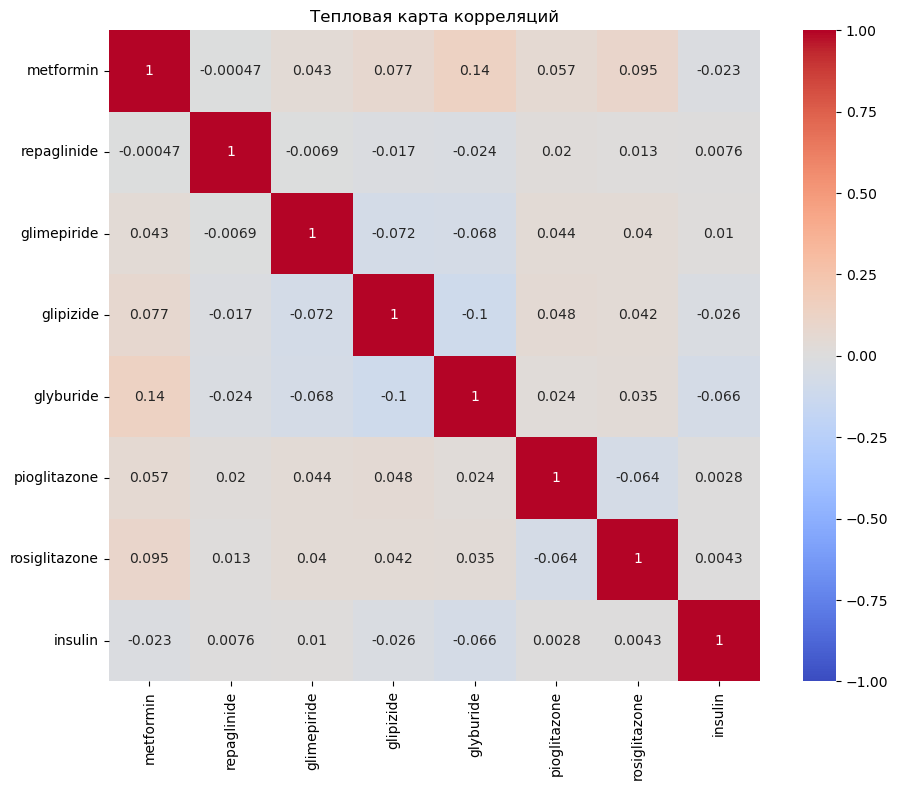

In [57]:
corr_matrix_drug = df_drug.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_drug, 
annot=True, 
cmap='coolwarm',
vmin=-1, vmax=1,

square=True) # 
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

По карте корреляций лекарства не коррелируют друг с другом, следовательно каждый столбик несет в себе уникальную информацию, можно создать агрегированный столбик и посмотреть как он влияет на качество модели, но удалять исходные не нужно.

In [38]:
df['drug_intensity'] = df_drug.sum(axis=1)


Групировка признаков - активность лечения

In [39]:
df_activ = df[['num_lab_procedures', 'num_procedures','num_medications','number_diagnoses']]

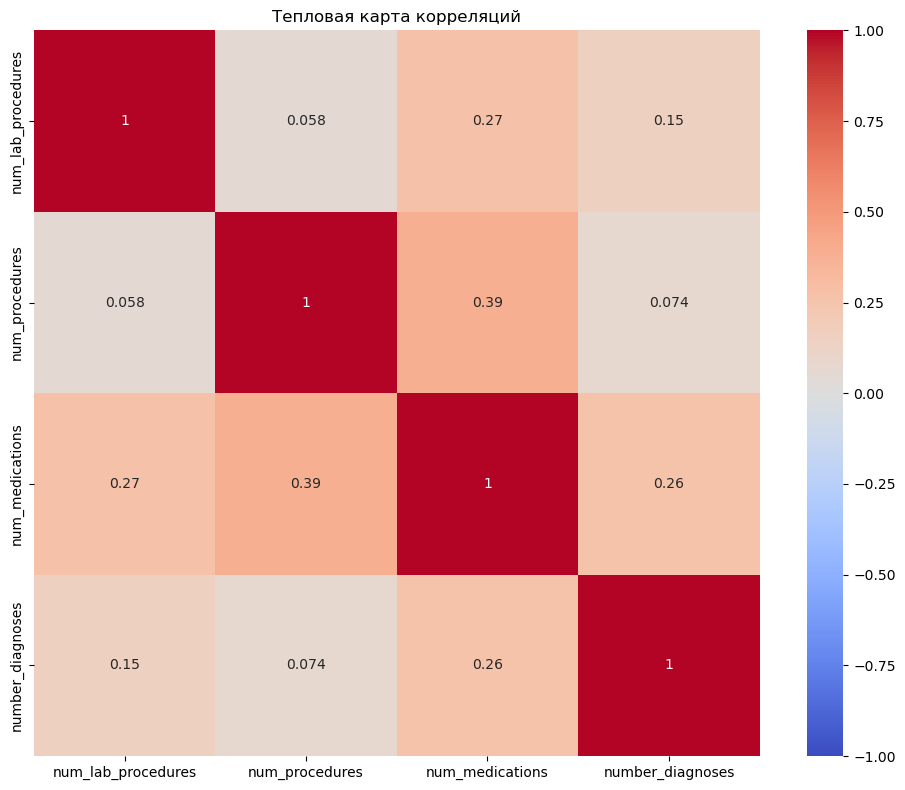

In [40]:
corr_matrix_activ = df_activ.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_activ, 
annot=True, 
cmap='coolwarm',
vmin=-1, vmax=1,
square=True) # 
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

Корреляции слабые, следовательно каждый столбик содержит уникальную информацию

In [41]:
df['activity'] = df_activ.sum(axis=1)

Группировка признаков - визиты

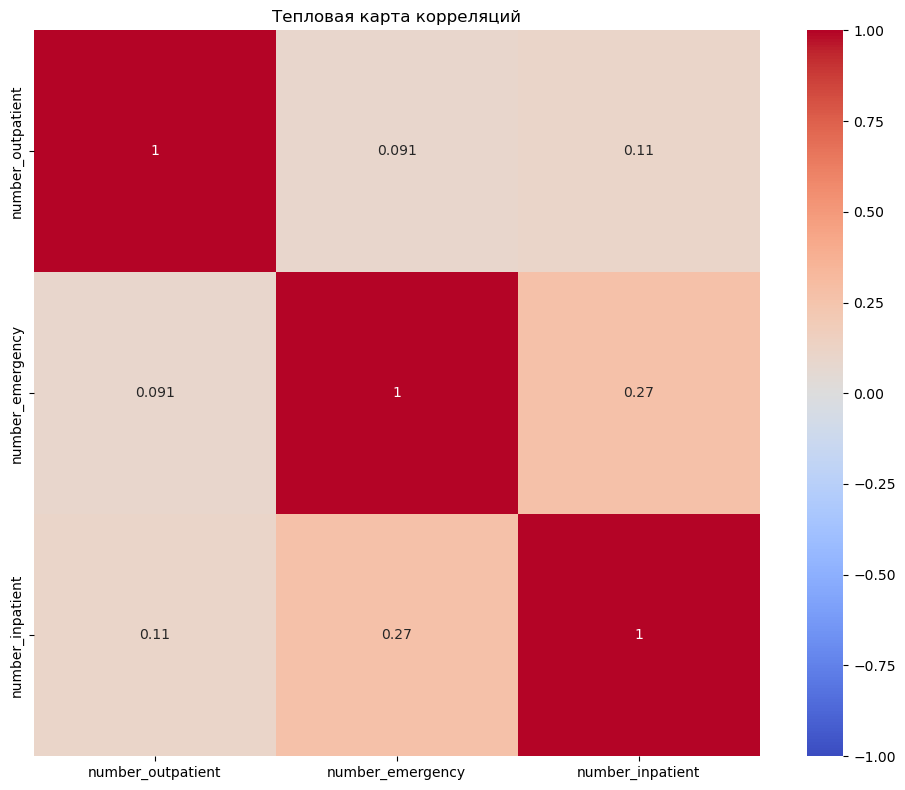

In [42]:
df_visits = df[['number_outpatient', 'number_emergency', 'number_inpatient']]

corr_matrix_visits = df_visits.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_visits, 
annot=True, 
cmap='coolwarm',
vmin=-1, vmax=1,
square=True) # 
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

Корреляции слабые, следовательно каждый столбик содержит уникальную информацию

In [43]:
df['total_visits'] = df_visits.sum(axis=1)

Группировка признаков - индифекаторы исхода, источника и типа госпитализации

In [44]:
df_adm =df[['admission_type_id', 'discharge_disposition_id', 'admission_source_id']]

Объединим редкие группы в одну

In [45]:
for i in df_adm:
    print(df[i].value_counts())


admission_type_id
1    53988
3    18868
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64
discharge_disposition_id
1     60232
3     13954
6     12902
18     3691
2      2128
22     1992
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64
admission_source_id
7     57492
1     29564
17     6781
4      3187
6      2264
2      1104
5       855
3       187
20      161
9       125
8        16
22       12
10        8
14        2
11        2
25        2
13        1
Name: count, dtype: int64


In [46]:
for i in df_adm:
    cat5 = df[i].value_counts(normalize=True) 
    categories = cat5[cat5 < 0.06].index
    print(categories)

    df[i] = df[i].apply(
    lambda x: 0 if x in categories else x
)

Index([6, 5, 8, 7, 4], dtype='int64', name='admission_type_id')
Index([18,  2, 22, 11,  5, 25,  4,  7, 23, 13, 14, 28,  8, 15, 24,  9, 17, 16,
       19, 10, 27, 12, 20],
      dtype='int64', name='discharge_disposition_id')
Index([4, 6, 2, 5, 3, 20, 9, 8, 22, 10, 14, 11, 25, 13], dtype='int64', name='admission_source_id')


In [47]:
df_adm =df[['admission_type_id', 'discharge_disposition_id', 'admission_source_id']]

Группировка признаков - демография

In [48]:
print(f'Список всех колонок: {df.columns.to_list()}')

Список всех колонок: ['gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'diabetes_flag', 'hypertension_flag', 'infection_flag', 'n_chronic_conditions', 'diag_1_Blood disorders', 'diag_1_Circulatory system', 'diag_1_Congenital anomalies', 'diag_1_Digestive system', 'diag_1_Endocrine/metabolic', 'diag_1_External causes', 'diag_1_Genitourinary system', 'diag_1_Infectious', 'diag_1_Injury/poisoning', 'diag_1_Mental disorders', 'diag_1_Musculoskeletal', 'diag_1_Neoplasms', 'diag_1_Nervous system', 'diag_1_Pregnancy', 

In [49]:
df_demograp = df[['gender', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'age', 'payer_code']]

Группировка признаков - диагноз

In [50]:
df_diag = df[['diag_1_Blood disorders', 'diag_1_Circulatory system', 'diag_1_Congenital anomalies', 'diag_1_Digestive system', 'diag_1_Endocrine/metabolic',
               'diag_1_External causes', 'diag_1_Genitourinary system', 'diag_1_Infectious', 'diag_1_Injury/poisoning', 'diag_1_Mental disorders', 'diag_1_Musculoskeletal',
                 'diag_1_Neoplasms', 'diag_1_Nervous system', 'diag_1_Pregnancy', 'diag_1_Respiratory system', 'diag_1_Skin', 'diag_1_Supplementary',
                   'diag_1_Symptoms/ill-defined', 'diag_1_Unknown', 'diag_2_Blood disorders', 'diag_2_Circulatory system', 'diag_2_Congenital anomalies', 'diag_2_Digestive system',
                     'diag_2_Endocrine/metabolic', 'diag_2_External causes', 'diag_2_Genitourinary system', 'diag_2_Infectious', 'diag_2_Injury/poisoning', 'diag_2_Mental disorders',
                       'diag_2_Musculoskeletal', 'diag_2_Neoplasms', 'diag_2_Nervous system', 'diag_2_Pregnancy', 'diag_2_Respiratory system', 'diag_2_Skin', 'diag_2_Supplementary',
                         'diag_2_Symptoms/ill-defined', 'diag_2_Unknown', 'diag_3_Blood disorders', 'diag_3_Circulatory system', 'diag_3_Congenital anomalies', 'diag_3_Digestive system',
                           'diag_3_Endocrine/metabolic', 'diag_3_External causes', 'diag_3_Genitourinary system', 'diag_3_Infectious', 'diag_3_Injury/poisoning', 'diag_3_Mental disorders',
                             'diag_3_Musculoskeletal', 'diag_3_Neoplasms', 'diag_3_Nervous system', 'diag_3_Pregnancy', 'diag_3_Respiratory system', 'diag_3_Skin', 'diag_3_Supplementary',
                               'diag_3_Symptoms/ill-defined', 'diag_3_Unknown']]

Группировка признаков - мед. специальность

In [51]:
df_med = df[['specialty_group_Allergy/Immunology', 'specialty_group_Anesthesiology', 'specialty_group_Cardiology', 'specialty_group_Dentistry', 'specialty_group_Dermatology',
     'specialty_group_ENT/Ophthalmology', 'specialty_group_Endocrinology', 'specialty_group_Gastroenterology', 'specialty_group_InfectiousDiseases', 'specialty_group_InternalMedicine',
       'specialty_group_Nephrology', 'specialty_group_Neurology', 'specialty_group_Ob/Gyn', 'specialty_group_Oncology/Hematology', 'specialty_group_Orthopedics/Sports',
         'specialty_group_Other', 'specialty_group_Podiatry', 'specialty_group_Psychiatry/Psychology', 'specialty_group_Pulmonology', 'specialty_group_Radiology/Pathology',
           'specialty_group_Rehabilitation', 'specialty_group_Rheumatology', 'specialty_group_Speech', 'specialty_group_Surgery',]]

Группировка признаков - анализы

In [52]:
df_an = df[[ 'max_glu_serum', 'A1Cresult',]]

Группировка признаков - агрегирующие

In [53]:
df_agreg = df[['total_visits', 'drug_intensity', 'activity']]

### 2.7. Преобразование признаков в бинарные индикаторы

In [54]:
df['time_in_hospital'].value_counts()

df['long_stay'] = (df['time_in_hospital'] > 7).astype(int)

In [55]:
df['drug_intensity'].value_counts()

df['long_drug_intensity'] = (df['drug_intensity'] < 5).astype(int)


In [56]:
df['total_visits'].value_counts()

df['long_total_visits'] = (df['total_visits'] < 6).astype(int)

In [57]:
df_binar = df[['long_stay', 'long_drug_intensity', 'long_total_visits']]

### 2.8. Взаимодействие между признаками

Основные гипотезы:  
* Частота госпитализаций зависит от возраста
* Гендерные различия в течение диабета
* Долгое пребывание и частота процедур - тяжелое состояние
* Инфекция и долгое пребывание - слабый организм, возможны осложнения

In [58]:
df['age_num_inpatient'] = df['age'] * df['number_inpatient']
df['gender_diabetes'] = df['gender'] * df['diabetesMed'].astype(int)
df['longstay_procedures'] = df['long_stay'] * df['num_procedures']
df['infection_time'] = df['infection_flag'] * df['time_in_hospital']

In [59]:
df_interaction = df[['age_num_inpatient', 'gender_diabetes', 'longstay_procedures', 'infection_time']]

Группировка оставшихся признаков

In [60]:
df_other = df[['diabetesMed', 'change']]
df_flag = df[['hypertension_flag', 'infection_flag', 'n_chronic_conditions',]]

In [61]:
for i in df_flag:
    print(df[i].unique())

[0 1]
[0 1]
[1 3 2 0]


In [82]:
df.drop(['diabetes_flag'], axis=1, inplace=True)

In [62]:
df.columns.to_list()

['gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'glimepiride',
 'glipizide',
 'glyburide',
 'pioglitazone',
 'rosiglitazone',
 'insulin',
 'change',
 'diabetesMed',
 'readmitted',
 'race_AfricanAmerican',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Other',
 'diabetes_flag',
 'hypertension_flag',
 'infection_flag',
 'n_chronic_conditions',
 'diag_1_Blood disorders',
 'diag_1_Circulatory system',
 'diag_1_Congenital anomalies',
 'diag_1_Digestive system',
 'diag_1_Endocrine/metabolic',
 'diag_1_External causes',
 'diag_1_Genitourinary system',
 'diag_1_Infectious',
 'diag_1_Injury/poisoning',
 'diag_1_Mental disorders',
 'diag_1_Musculoskeletal',
 'diag_1_Neoplasms',
 'diag_1_Nervous sy

In [88]:
df.shape

(101763, 126)

### 2.9 Масштабирование количественных признаков
### Масштабирование количественных признаков  следует проводить после разделения данных на обучающую и тестовую выборки, чтобы избежать утечки!!! Это гарантирует, что модель не увидит информацию о распределении данных в тестовой выборке до её оценки.

1.  Группы, которые будут в каждом собранном датасете:  
Демография - df_demograp  
Диагнозы - df_diag  
Мед. спец - df_med  
diabetesMed/изменения - df_other
Индификатор исхода/тип госпитализации - df_adm  
Анализы - df_an 
df['long_stay'] 
    
2.  Группы с агрегацией(здесь мы выбираем, либо исходные стобики, либо агрегирующие, либо всё вместе):  
Лекарства - df_drug
Активность лечения - df_activ
Кол-во визитов - df_visits
  
или все это в агрегирующем состоянии df_agreg

3.  Бинарные признаки(не используем вместе с агрегирующими df_binar)
Важные заболевания - df_flag
Время в госпитале/кол-во лекарств/кол-во визитов - df_binar (минус df['long_stay'] из основы, поскольку в бинар повтор)

4.  Взаимодействие(обычно только для линейных моделей):
df_interaction

In [64]:
df1 = pd.concat([
    df_demograp, df_diag, df_med, df_other, df_adm, df_an,
    df[['long_stay']], df_drug, df_activ, df_visits, df_flag
], axis=1)

df2 = pd.concat([
    df_demograp, df_diag, df_med, df_other, df_adm, df_an,
    df[['long_stay']], df_drug, df_activ, df_visits, df_flag, df_agreg
], axis=1)

df3 = pd.concat([
    df_demograp, df_diag, df_med, df_other, df_adm, df_an,
    df[['long_stay']], df_flag, df_agreg
], axis=1)

df4 = pd.concat([
    df_demograp, df_diag, df_med, df_other, df_adm, df_an, df_flag, df_binar
], axis=1)

df5 = pd.concat([
    df4, df_interaction
], axis=1)

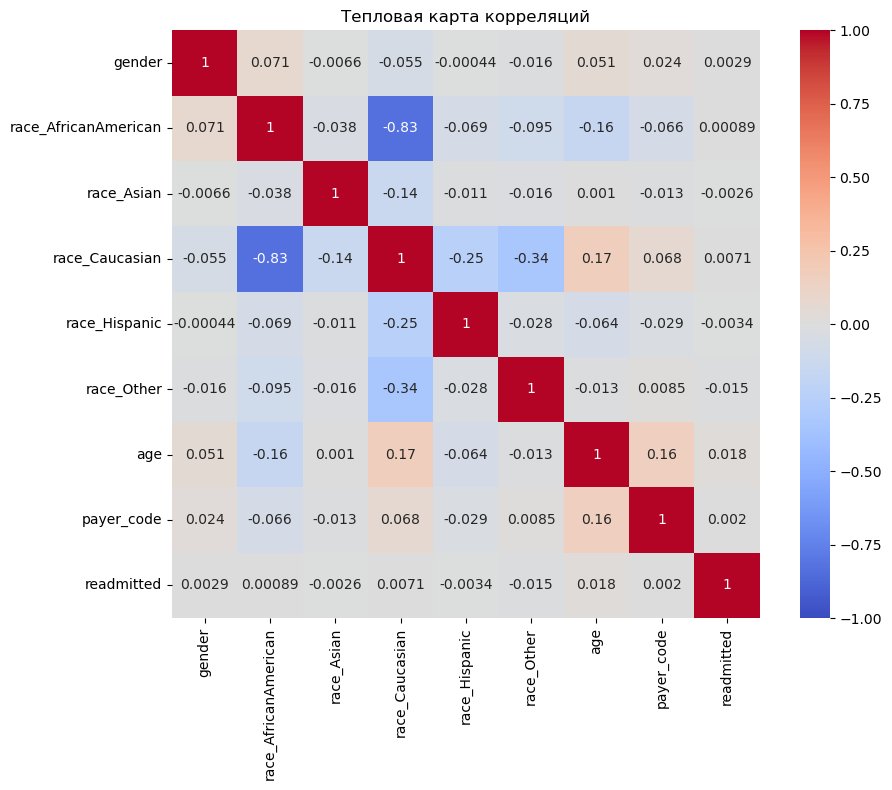

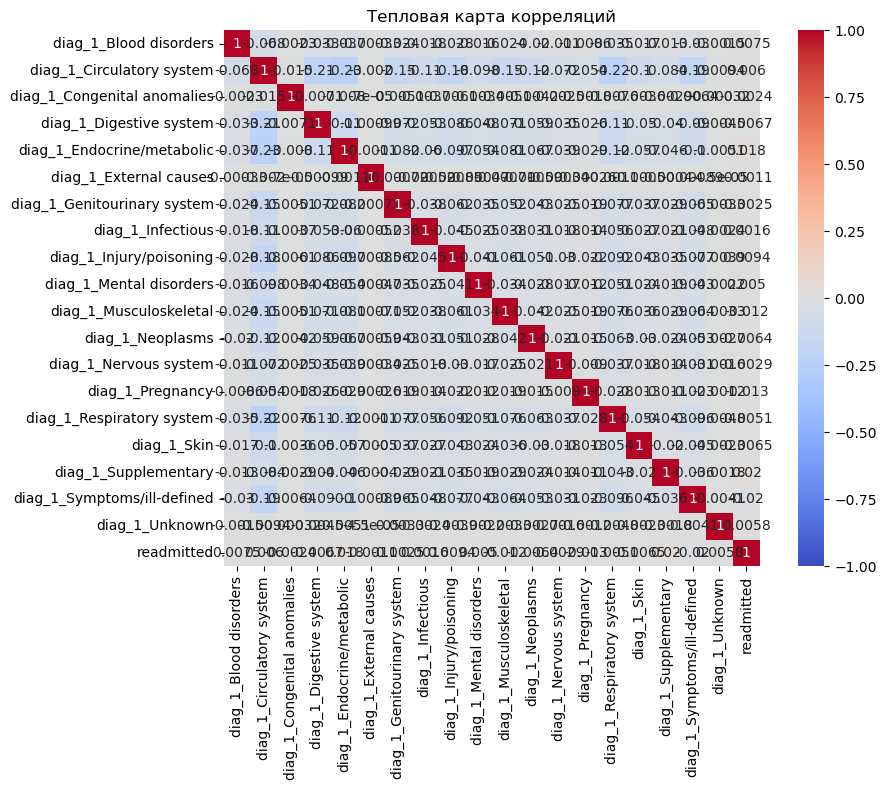

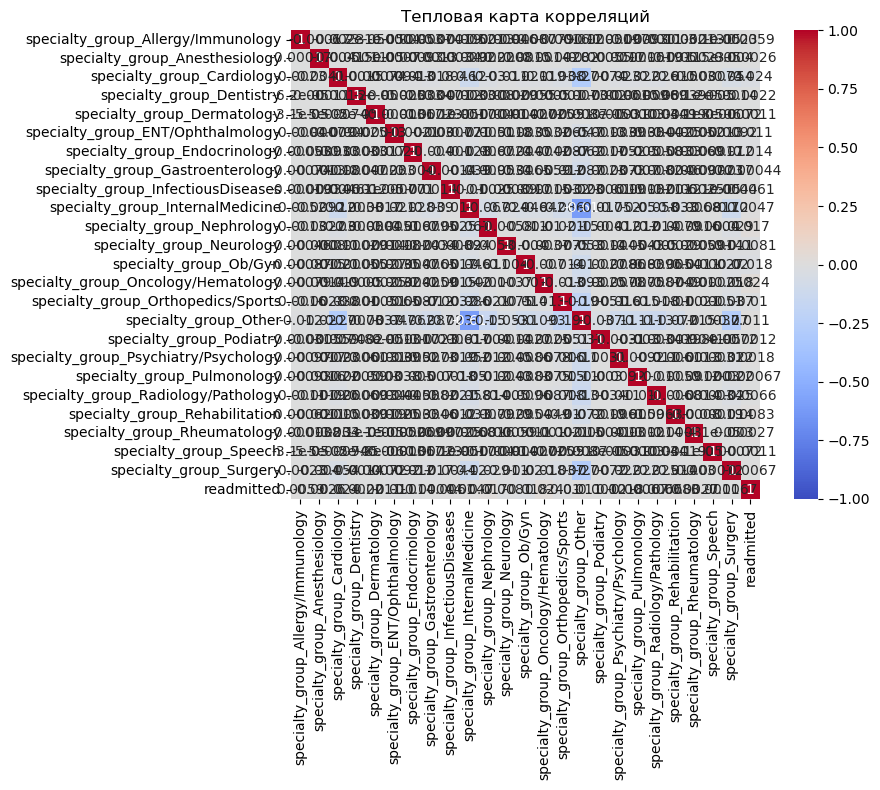

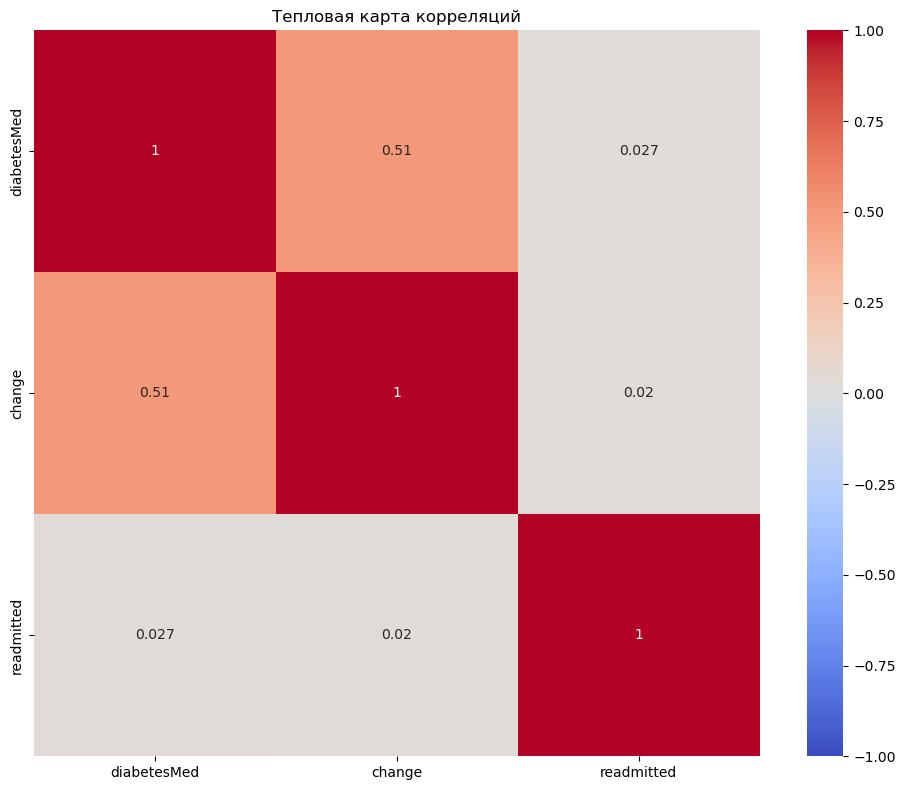

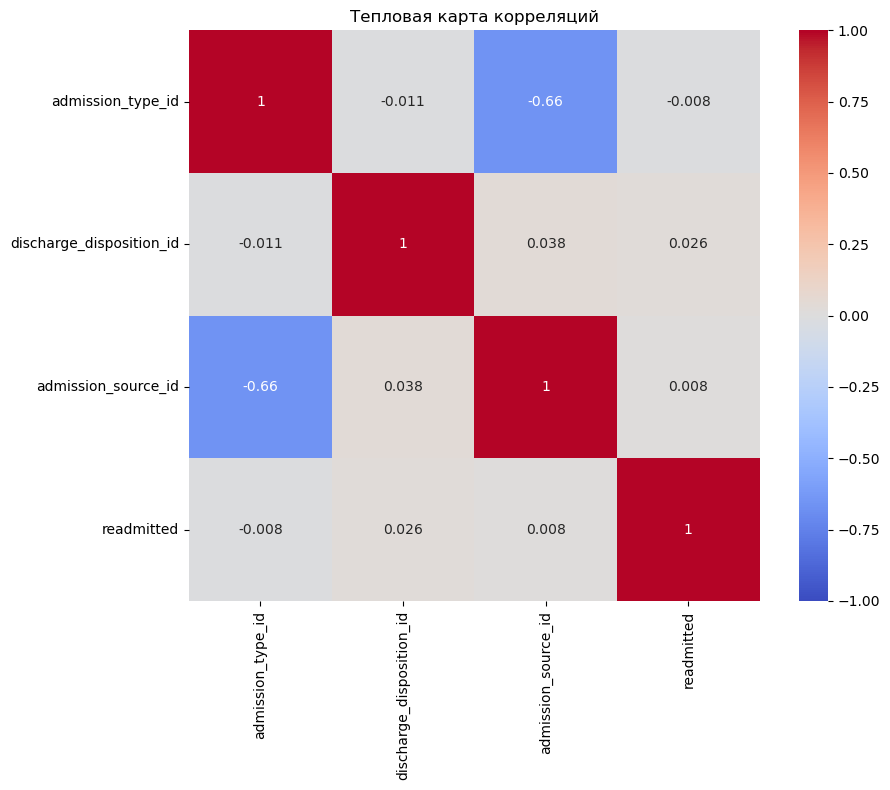

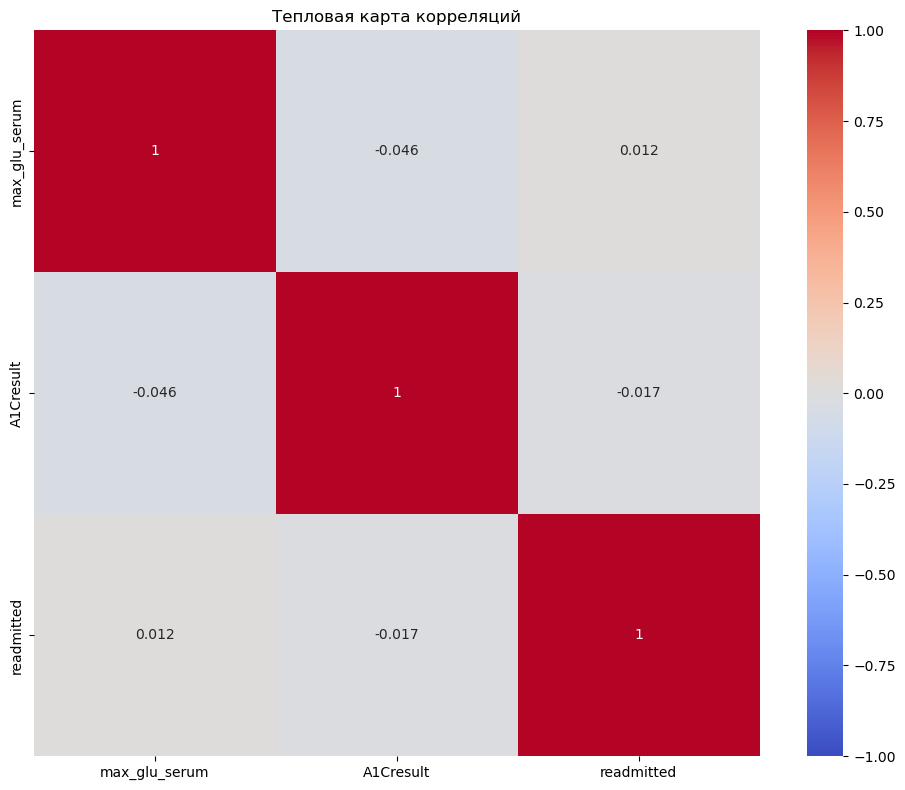

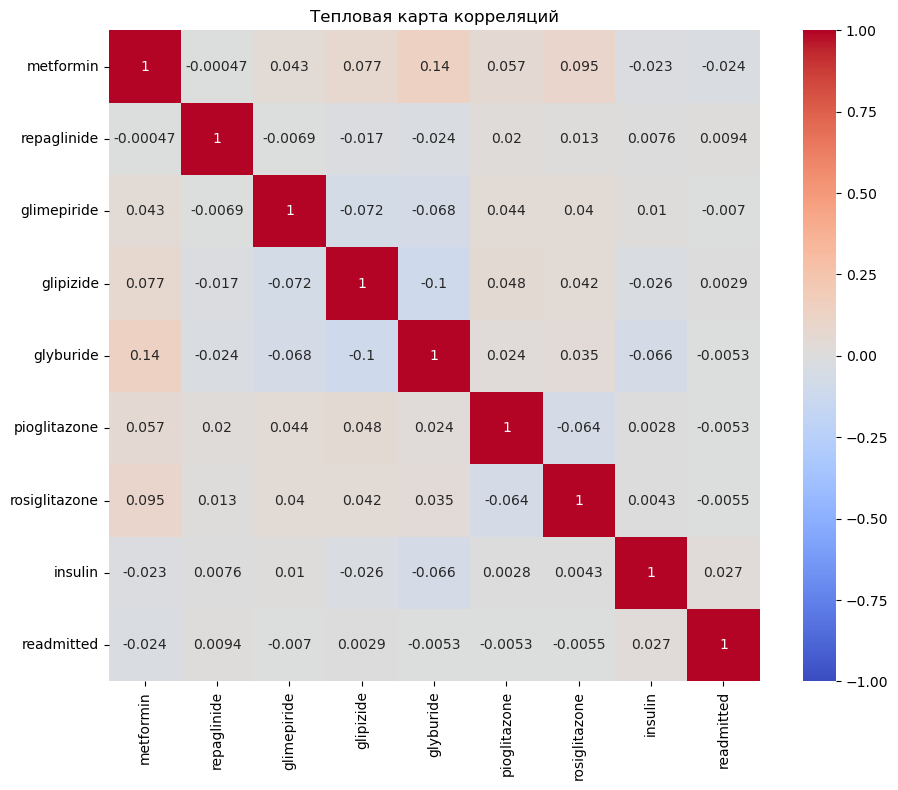

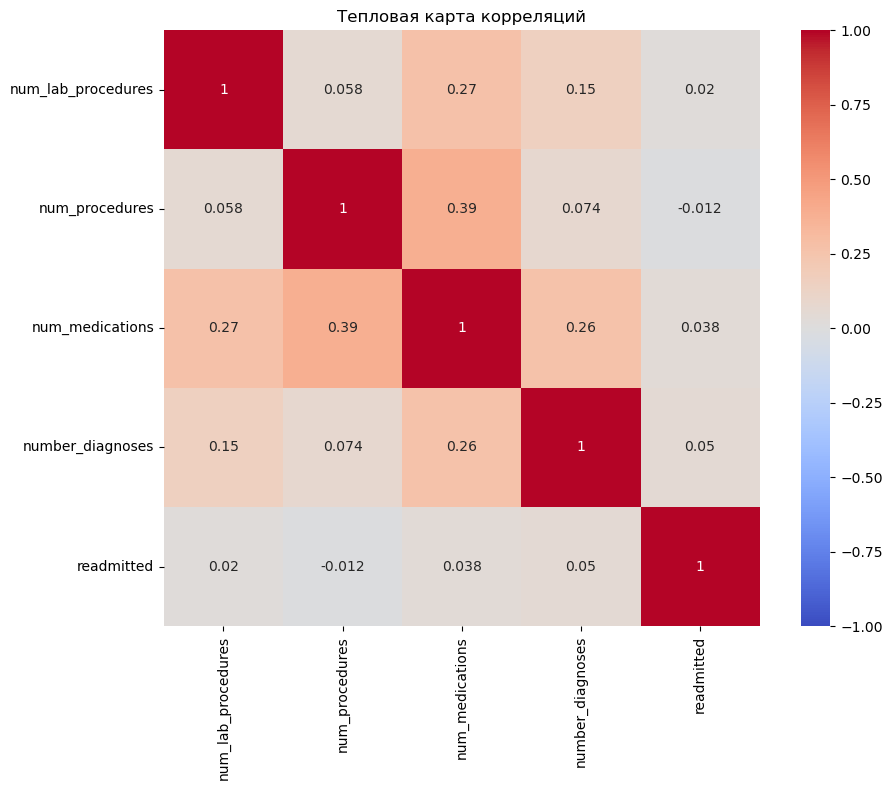

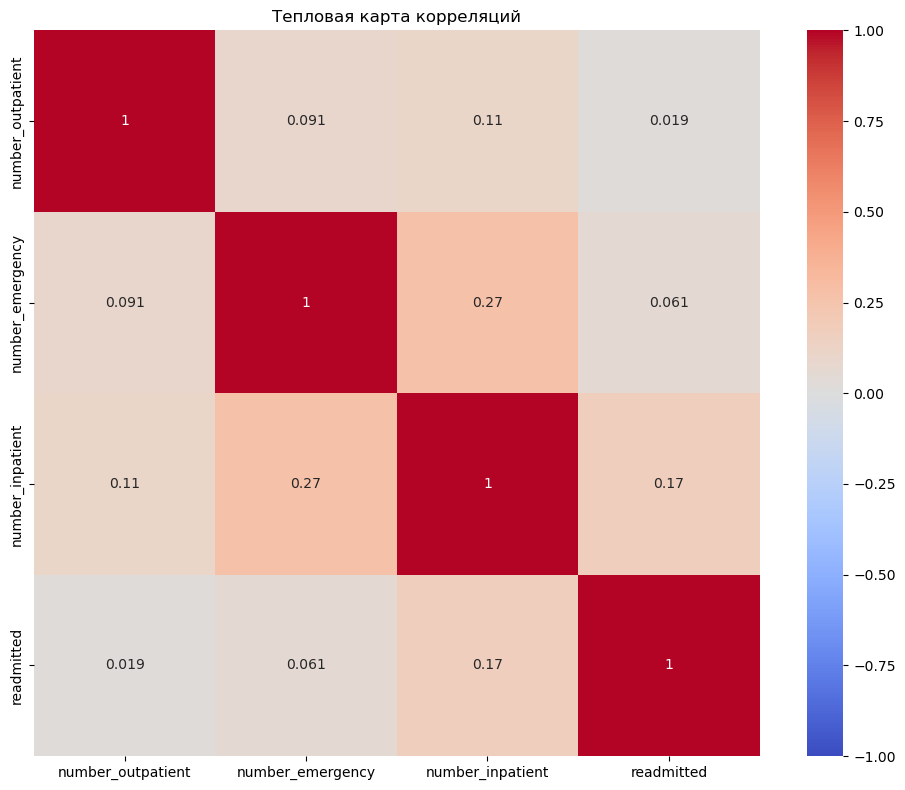

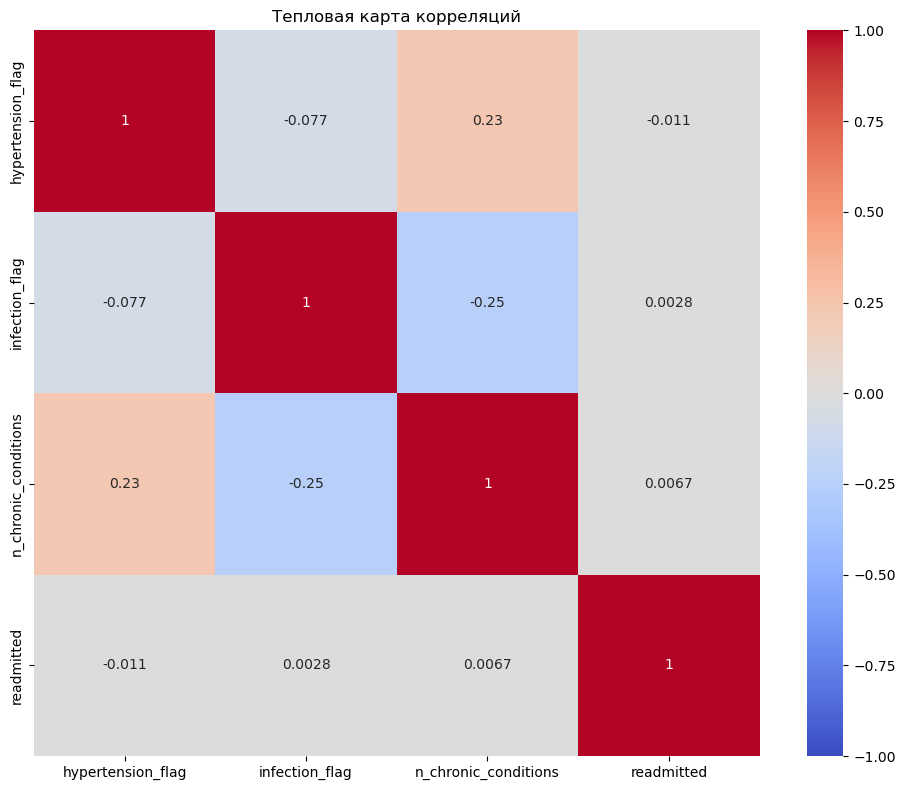

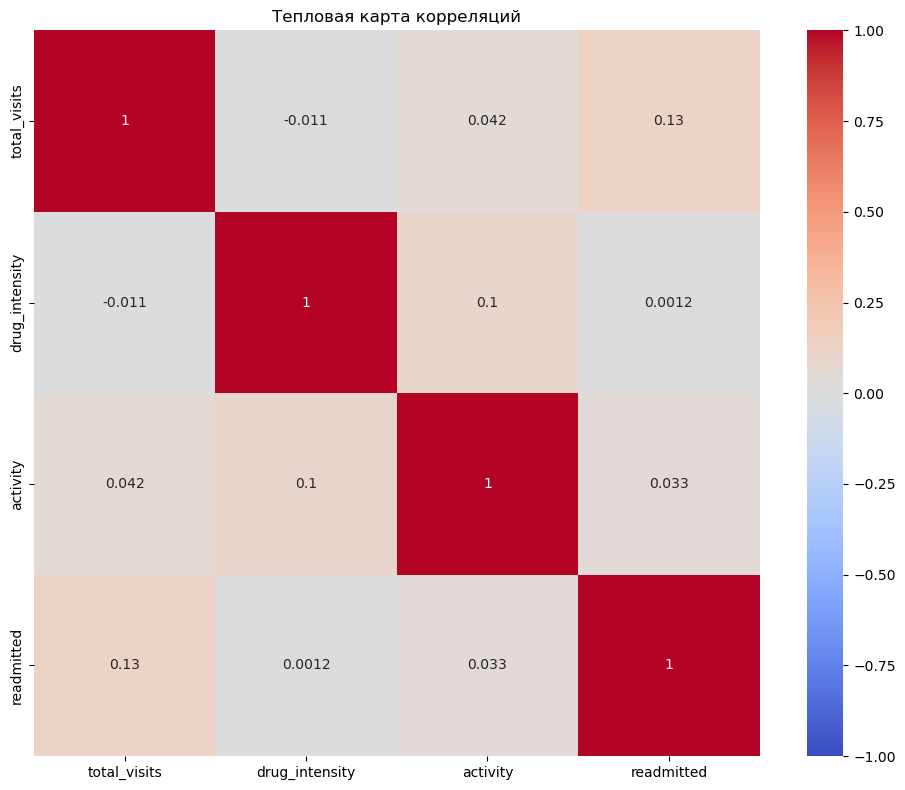

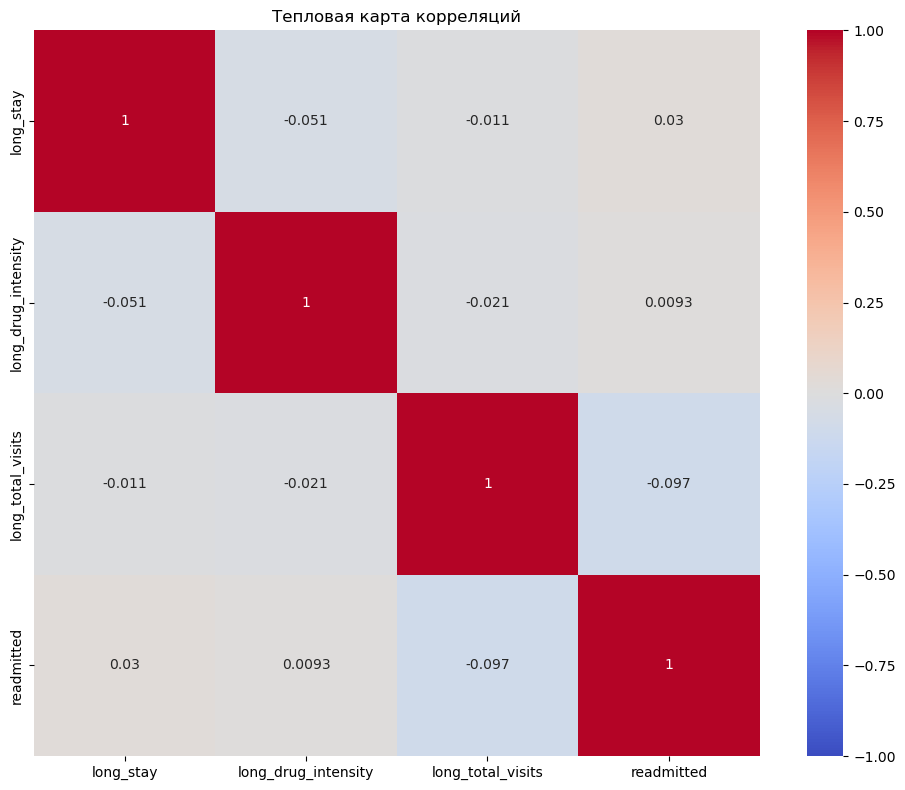

In [65]:
df_all = [df_demograp, df[['diag_1_Blood disorders',
 'diag_1_Circulatory system',
 'diag_1_Congenital anomalies',
 'diag_1_Digestive system',
 'diag_1_Endocrine/metabolic',
 'diag_1_External causes',
 'diag_1_Genitourinary system',
 'diag_1_Infectious',
 'diag_1_Injury/poisoning',
 'diag_1_Mental disorders',
 'diag_1_Musculoskeletal',
 'diag_1_Neoplasms',
 'diag_1_Nervous system',
 'diag_1_Pregnancy',
 'diag_1_Respiratory system',
 'diag_1_Skin',
 'diag_1_Supplementary',
 'diag_1_Symptoms/ill-defined',
 'diag_1_Unknown']], df_med, df_other, df_adm, df_an, df_drug, df_activ, df_visits, df_flag, df_agreg, df_binar]

for dfi in df_all:
    dfi = pd.concat([dfi, df['readmitted']], axis = 1)
    corr_matrix = dfi.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, 
    annot=True, 
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True) # 
    plt.title('Тепловая карта корреляций')
    plt.tight_layout()
    plt.show()

### Посмотрев тепловые карты для всех подгрупп можно сделать вывод, что линейной зависимости с целевой переменной нет, логистическая регрессия вероятнее всего будет давать плохой результат. Деревья могут выявить нелинейные зависимости.

### 3. Ответы на вопросы:

#### Вопрос 1: обработка пропусков
1. Были удалены столбцы с очень большим количеством пропусков, более 90-95%, никакой информации модели они не дадут.
2. Заменены пропуски на 'неизвестно' в двух ключевых лабораторных признаков для диабета, это важная информация для модели, но много пропусков поскольку в датасете присутствуют заболевание всех областей, а не только болезни крови. Такая же логика была применена к столбцам медицинская специальность и код плательщика.
3. Для столбца раса были посмотрены распределения пропусков и значения другие, поскольку распределения по целевой переменной одинаковые, было принято решение их объединить.
4. Для столбца пол было принято решение удалить строки с пропусками, поскольку тяжело ипутировать, а также их всего 3 и по целевой переменной они относились к мажоритарному классу.
5. Для диагнозов было принято решения заменить пропуски на неизвестно, поскольку есть вероятность, что диагноз не удалось поставить.  
#### Вопрос 2: стратегии инженирии признаков
1. Для начала просмотрев столбцы можно выяснить какую именно информацию мы можем достать из датасета. Например если бы у нас был только столбец с мед. специальностью, то мы бы доставали от туда область болезни, но поскольку у нас есть столбец диагноз и вопрос с областью закрыт, из мед. специальности мы можем достать тип лечения, так как терапевтическая кардиология и хирургическая дают представление о степени тяжести состояния пациента. Из столбца код плательщика можно предположить финансовое состояние пациента.
2. Объединение в смысловые группы и последующий просмотр корреляции, если бы признаки коррелировали между друг другом, что может вызывать проблемы для моделей, особенно для регресии.
3. Для групп были созданы агрегирующие признаки. Можно протестировать модель без них с основными столбцами, с основными столбцами и с агрегирующими, и только с агрегирующими. Разница может быть существенной между этими моделями.
4. Было выдвинуто 4 гипотезы о взаимодействии между признаками. Это добавляет модели нелинейность. Важно для линейной регрессии, где неучитывается нелинейность.


## Задание 3. Построение и сравнение моделей

### 3.1. Разделение данных на обучающую, тестовую и валидационную выборки

In [66]:
X1 = df1
X2 = df2
X3 = df3
X4 = df4
X5 = df5

y = df['readmitted']

In [67]:
# Для первого датасета
X1_train_val, X1_test, y1_train_val, y1_test = train_test_split(
    X1, y, test_size=0.2, random_state=42, stratify=y
)
X1_train, X1_val, y1_train, y1_val = train_test_split(
    X1_train_val, y1_train_val, test_size=0.25, random_state=42, stratify=y1_train_val
)

# Для второго датасета
X2_train_val, X2_test, y2_train_val, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_train_val, y2_train_val, test_size=0.25, random_state=42, stratify=y2_train_val
)

# Для третьего датасета
X3_train_val, X3_test, y3_train_val, y3_test = train_test_split(
    X3, y, test_size=0.2, random_state=42, stratify=y
)
X3_train, X3_val, y3_train, y3_val = train_test_split(
    X3_train_val, y3_train_val, test_size=0.25, random_state=42, stratify=y3_train_val
)

# Для четвертого датасета
X4_train_val, X4_test, y4_train_val, y4_test = train_test_split(
    X4, y, test_size=0.2, random_state=42, stratify=y
)
X4_train, X4_val, y4_train, y4_val = train_test_split(
    X4_train_val, y4_train_val, test_size=0.25, random_state=42, stratify=y4_train_val
)

# Для четвертого датасета
X5_train_val, X5_test, y5_train_val, y5_test = train_test_split(
    X5, y, test_size=0.2, random_state=42, stratify=y
)
X5_train, X5_val, y5_train, y5_val = train_test_split(
    X5_train_val, y5_train_val, test_size=0.25, random_state=42, stratify=y5_train_val
)

Проверка распределения целевой переменной

In [68]:
y1_total = [y1_train, y1_val,  y1_test]
for i in y1_total:
    print(i.value_counts(normalize=True))

readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
readmitted
0    0.88837
1    0.11163
Name: proportion, dtype: float64
readmitted
0    0.888419
1    0.111581
Name: proportion, dtype: float64


Масштабируем числовые признаки (только на трейне)

In [69]:
X_train_total = [ X1_train, X2_train, X3_train, X4_train, X5_train]
X_test_total = [ X1_test, X2_test, X3_test, X4_test, X5_test]
y_train_total = [y1_train, y2_train, y3_train, y4_train, y5_train]
y_test_total = [y1_test, y2_test, y3_test, y4_test, y5_test]  

In [70]:
robust_cols = {
    1: ['num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'],
    2: ['num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'activity', 'total_visits'],
    3: ['activity', 'total_visits'],
    4: [],
    5: [],
}

minmax_cols = {
    1: ['num_procedures', 'number_diagnoses', 'age'],
    2: ['num_procedures', 'number_diagnoses', 'drug_intensity', 'age'],
    3: ['drug_intensity', 'age'],
    4: ['age'],
    5: ['age_num_inpatient', 'gender_diabetes', 'longstay_procedures', 'infection_time'],
}


scalers_robust = {}
scalers_minmax = {}

for idx, dfi in enumerate(X_train_total, start=1):
    if robust_cols[idx]:
        scaler_r = RobustScaler()
        dfi[robust_cols[idx]] = scaler_r.fit_transform(dfi[robust_cols[idx]])
        scalers_robust[idx] = scaler_r 
    if minmax_cols[idx]:
        scaler_m = MinMaxScaler()
        dfi[minmax_cols[idx]] = scaler_m.fit_transform(dfi[minmax_cols[idx]])
        scalers_minmax[idx] = scaler_m 

for idx, dfi in enumerate(X_test_total, start=1):
    if robust_cols[idx]:
        dfi[robust_cols[idx]] = scalers_robust[idx].transform(dfi[robust_cols[idx]])
    if minmax_cols[idx]:
        dfi[minmax_cols[idx]] = scalers_minmax[idx].transform(dfi[minmax_cols[idx]])

Семплинг

In [71]:
smote_tomek = SMOTETomek(random_state=42)

X_train_total_res, y_train_total_res = [], []

for idx, (Xtr, ytr) in enumerate(zip(X_train_total, y_train_total), start=1):
    X_res, y_res = smote_tomek.fit_resample(Xtr, ytr)
    X_train_total_res.append(X_res)
    y_train_total_res.append(y_res)

    print(f"\nX{idx}_train:")
    print("До SMOTE + Tomek:", ytr.value_counts(normalize=True))
    print("После SMOTE + Tomek:", y_res.value_counts(normalize=True))


X1_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X2_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X3_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X4_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X5_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64


In [102]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

for idx, (Xtr, ytr, Xte, yte) in enumerate(zip(X_train_total_res, y_train_total_res, X_test_total, y_test_total), start=1):
    print('-'*70)
    print(f"\nДатасет X{idx}")
    
    for name, model in models.items():
        # Копируем модель, чтобы каждый раз обучалась с нуля
        clf = model
        clf.fit(Xtr, ytr)
        y_pred = clf.predict(Xte)
        
        print(f"\n{name}")
        print(classification_report(yte, y_pred))

----------------------------------------------------------------------

Датасет X1

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.71      0.80     18082
           1       0.14      0.39      0.21      2271

    accuracy                           0.68     20353
   macro avg       0.52      0.55      0.50     20353
weighted avg       0.82      0.68      0.73     20353


Decision Tree
              precision    recall  f1-score   support

           0       0.89      0.87      0.88     18082
           1       0.15      0.18      0.16      2271

    accuracy                           0.80     20353
   macro avg       0.52      0.53      0.52     20353
weighted avg       0.81      0.80      0.80     20353


Random Forest
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.42      0.01      0.02      2271

    accuracy                           0.89     

#### Сравнение моделей по F1-score для класса 1 для изначально созданных моделей с семплингом

| Набор | Logistic Regression | Decision Tree | Random Forest |
|-------|-------------------|---------------|---------------|
| X1    | 0.21              | 0.16          | 0.02          | 
| X2    | 0.21              | 0.15          | 0.02          | 
| X3    | 0.21              | 0.16          | 0.02          |
| X4    | 0.19              | 0.15          | 0.07          |
| X5    | 0.20              | 0.16          | 0.05          |


* Logistic Regression: стабильно относительно неплохой recall и F1-score, но всё ещё низкая точность.

* Decision Tree: лучше баланс precision/recall, но F1-score для редкого класса всё ещё низкий.

* Random Forest: высокая точность на основном классе, почти полностью игнорирует редкий класс

In [72]:
diag_2_3 = ['diag_2_Blood disorders', 'diag_2_Circulatory system', 'diag_2_Congenital anomalies', 'diag_2_Digestive system', 'diag_2_Endocrine/metabolic', 'diag_2_External causes', 'diag_2_Genitourinary system', 'diag_2_Infectious', 'diag_2_Injury/poisoning', 'diag_2_Mental disorders', 'diag_2_Musculoskeletal', 'diag_2_Neoplasms', 'diag_2_Nervous system', 'diag_2_Pregnancy', 'diag_2_Respiratory system', 'diag_2_Skin', 'diag_2_Supplementary', 'diag_2_Symptoms/ill-defined', 'diag_2_Unknow', 'diag_3_Blood disorders', 'diag_3_Circulatory system', 'diag_3_Congenital anomalies', 'diag_3_Digestive system', 'diag_3_Endocrine/metabolic', 'diag_3_External causes', 'diag_3_Genitourinary system', 'diag_3_Infectious', 'diag_3_Injury/poisoning', 'diag_3_Mental disorders', 'diag_3_Musculoskeletal', 'diag_3_Neoplasms', 'diag_3_Nervous system', 'diag_3_Pregnancy', 'diag_3_Respiratory system', 'diag_3_Skin', 'diag_3_Supplementary', 'diag_3_Symptoms/ill-defined', 'diag_3_Unknow']
df_race = df_demograp[['race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other']]

In [73]:
cols_to_drop = list(df_diag.columns) + list(df_med.columns) + list(df_an.columns) + \
               list(df_adm.columns) + list(df_race.columns) + ['payer_code']

def drop_cols(X_train, X_val, X_test, cols):
    return X_train.drop(cols, axis=1), X_val.drop(cols, axis=1), X_test.drop(cols, axis=1)

# Применяем
X1new_train, X1new_val, X1new_test = drop_cols(X1_train, X1_val, X1_test, cols_to_drop)
X2new_train, X2new_val, X2new_test = drop_cols(X2_train, X2_val, X2_test, cols_to_drop)
X3new_train, X3new_val, X3new_test = drop_cols(X3_train, X3_val, X3_test, cols_to_drop)
X4new_train, X4new_val, X4new_test = drop_cols(X4_train, X4_val, X4_test, cols_to_drop)
X5new_train, X5new_val, X5new_test = drop_cols(X5_train, X5_val, X5_test, cols_to_drop)

In [74]:
X_train_total_new = [ X1new_train, X2new_train, X3new_train, X4new_train, X5new_train]
X_test_total_new = [ X1new_test, X2new_test, X3new_test, X4new_test, X5new_test]
y_train_total_new = [y1_train, y2_train, y3_train, y4_train, y5_train]
y_test_total_new = [y1_test, y2_test, y3_test, y4_test, y5_test]  

In [75]:
robust_cols = {
    1: ['num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'],
    2: ['num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'activity', 'total_visits'],
    3: ['activity', 'total_visits'],
    4: [],
    5: [],
}

minmax_cols = {
    1: ['num_procedures', 'number_diagnoses', 'age'],
    2: ['num_procedures', 'number_diagnoses', 'drug_intensity', 'age'],
    3: ['drug_intensity', 'age'],
    4: ['age'],
    5: ['age_num_inpatient', 'gender_diabetes', 'longstay_procedures', 'infection_time'],
}


scalers_robust = {}
scalers_minmax = {}

for idx, dfi in enumerate(X_train_total_new, start=1):
    if robust_cols[idx]:
        scaler_r = RobustScaler()
        dfi[robust_cols[idx]] = scaler_r.fit_transform(dfi[robust_cols[idx]])
        scalers_robust[idx] = scaler_r 
    if minmax_cols[idx]:
        scaler_m = MinMaxScaler()
        dfi[minmax_cols[idx]] = scaler_m.fit_transform(dfi[minmax_cols[idx]])
        scalers_minmax[idx] = scaler_m 

for idx, dfi in enumerate(X_test_total_new, start=1):
    if robust_cols[idx]:
        dfi[robust_cols[idx]] = scalers_robust[idx].transform(dfi[robust_cols[idx]])
    if minmax_cols[idx]:
        dfi[minmax_cols[idx]] = scalers_minmax[idx].transform(dfi[minmax_cols[idx]])

In [76]:
smote_tomek_new = SMOTETomek(random_state=42)

X_train_total_res_new, y_train_total_res_new = [], []

for idx, (Xtr, ytr) in enumerate(zip(X_train_total_new, y_train_total_new), start=1):
    X_res, y_res = smote_tomek_new.fit_resample(Xtr, ytr)
    X_train_total_res_new.append(X_res)
    y_train_total_res_new.append(y_res)

    print(f"\nX{idx}_train:")
    print("До SMOTE + Tomek:", ytr.value_counts(normalize=True))
    print("После SMOTE + Tomek:", y_res.value_counts(normalize=True))


X1_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X2_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X3_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X4_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X5_train:
До SMOTE + Tomek: readmitted
0    0.888399
1    0.111601
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64


In [108]:
models_new = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

for idx, (Xtr, ytr, Xte, yte) in enumerate(zip(X_train_total_res_new, y_train_total_res_new, X_test_total_new, y_test_total_new), start=1):
    print('-'*70)
    print(f"\nДатасет X{idx}")
    
    for name, model in models_new.items():
        # Копируем модель, чтобы каждый раз обучалась с нуля
        clf = model
        clf.fit(Xtr, ytr)
        y_pred = clf.predict(Xte)
        
        print(f"\n{name}")
        print(classification_report(yte, y_pred))

----------------------------------------------------------------------

Датасет X1

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.64      0.75     18082
           1       0.15      0.51      0.23      2271

    accuracy                           0.62     20353
   macro avg       0.53      0.57      0.49     20353
weighted avg       0.83      0.62      0.69     20353


Decision Tree
              precision    recall  f1-score   support

           0       0.89      0.86      0.88     18082
           1       0.13      0.16      0.14      2271

    accuracy                           0.78     20353
   macro avg       0.51      0.51      0.51     20353
weighted avg       0.81      0.78      0.79     20353


Random Forest
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18082
           1       0.26      0.03      0.06      2271

    accuracy                           0.88     

Для урезанных моделей результат стал лучше

### 3.3. Кросс-валидация и поиск гиперпараметров (GridSearchCV).

Дисклеймер:  
1. Собрано несколько вариантов датасетов X1-X5 основные, которые были описаны при построении в задании 3.2. Далее с пометкой res это те же данные, но с семплингом. Х1new-X5new, это модифицированные основные датасеты, где было удалено несколько столбцов, которые возможно создают шум. Аналагично Х1new-X5new с пометкой res это данные с семплингом. Таким образом имеется 20 датафреймов. 
2. Для поиска гиперпараметров были выбпаны метрики f1_score и recall по 1 классу. Поскольку нам важно выявить именно 1 класс, но без сильного ущерба для 0. 
3. Для каждого из 20 датасетов обучены три модели (лог регрессия, дерево решений, случайный лес) с f1_score и recall, получается 120 моделей  
  
  ВАЖНО! Эти 120 моделей изначально будут сравниваться по f1 и recall для 1 класса, и только потом для отобранных уже будут строиться ROC AUC и confusion matrix.

#### Логистическая регрессия

Обучение с F1

In [109]:
param_grid_logreg = [
    # для L1
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [0.00001, 0.0001, 0.001],
        'max_iter': [500]
    },
    # для L2
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'sag', 'saga'],
        'C': [ 0.00001, 0.0001, 0.001],
        'max_iter': [500]
    }
]


In [110]:
datasets = {
    "X1": (X_train_total_res[0], X1_test, y_train_total_res[0], y1_test),
    "X2": (X_train_total_res[1], X2_test, y_train_total_res[1], y2_test),
    "X3": (X_train_total_res[2], X3_test, y_train_total_res[2], y3_test),
    "X4": (X_train_total_res[3], X4_test, y_train_total_res[3], y4_test),
    "X5": (X_train_total_res[4], X5_test, y_train_total_res[4], y5_test),
    "X12": (X_train_total_res_new[0], X1new_test, y_train_total_res_new[0], y1_test),
    "X22": (X_train_total_res_new[1], X2new_test, y_train_total_res_new[1], y2_test),
    "X32": (X_train_total_res_new[2], X3new_test, y_train_total_res_new[2], y3_test),
    "X42": (X_train_total_res_new[3], X4new_test, y_train_total_res_new[3], y4_test),
    "X52": (X_train_total_res_new[4], X5new_test, y_train_total_res_new[4], y5_test),
    "X21": (X1_train, X1_test, y1_train, y1_test),
    "X22": (X2_train, X2_test, y2_train, y2_test),
    "X23": (X3_train, X3_test, y3_train, y3_test),
    "X24": (X4_train, X4_test, y4_train, y4_test),
    "X25": (X5_train, X5_test, y5_train, y5_test),
    "X212": (X1new_train, X1new_test, y_train_total_new[0], y1_test),
    "X222": (X2new_train, X2new_test, y_train_total_new[1], y2_test),
    "X232": (X3new_train, X3new_test, y_train_total_new[2], y3_test),
    "X242": (X4new_train, X4new_test, y_train_total_new[3], y4_test),
    "X252": (X5new_train, X5new_test, y_train_total_new[4], y5_test),
}
scorer = make_scorer(f1_score, pos_label=1)
results = {}

for name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"\nLogisticRegression для {name}")
    tree = LogisticRegression(random_state=42, class_weight='balanced')
    grid = GridSearchCV(tree, param_grid_logreg, cv=5, scoring=scorer, n_jobs=-1, verbose=2)
    grid.fit(X_train, y_train)

    print("Лучшие параметры:", grid.best_params_)
    print("Лучший F1:", grid.best_score_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print(f"Classification Report ({name})")
    print(classification_report(y_test, y_pred, digits=3))
    
    results[name] = {
        "best_params": grid.best_params_,
        "best_f1": grid.best_score_,
        "classification_report": classification_report(y_test, y_pred, digits=3)
    }
    print('-'*70)


LogisticRegression для X1
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'C': 0.001, 'max_iter': 500, 'penalty': 'l2', 'solver': 'saga'}
Лучший F1: 0.6691433855063832
Classification Report (X1)
              precision    recall  f1-score   support

           0      0.905     0.688     0.782     18082
           1      0.147     0.426     0.218      2271

    accuracy                          0.659     20353
   macro avg      0.526     0.557     0.500     20353
weighted avg      0.821     0.659     0.719     20353

----------------------------------------------------------------------

LogisticRegression для X2
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'C': 0.001, 'max_iter': 500, 'penalty': 'l2', 'solver': 'sag'}
Лучший F1: 0.6703640135221091
Classification Report (X2)
              precision    recall  f1-score   support

           0      0.905     0.690     0.783     18082
           1      0.146     0.423     

| Модель | Лучший F1 (train CV) | F1 (класс 1) | Recall (класс 1) |
|:-------|:---------------------:|:-------------:|:----------------:|
| X1     | 0.6691 | 0.218 | 0.427 |
| X2     | 0.6704 | 0.217 | 0.423 |
| X3     | 0.6368 | 0.213 | 0.446 |
| X4     | 0.6667 | 0.201 | 1.000 |
| X5     | 0.6707 | 0.195 | 0.377 |
| X12    | 0.5781 | 0.232 | 0.480 |
| X22    | 0.2501 | 0.261 | 0.500 |
| X32    | 0.5842 | 0.238 | 0.577 |
| X42    | 0.6667 | 0.000 | 0.000 |
| X52    | 0.6667 | 0.201 | 1.000 |
| X21    | 0.2500 | 0.260 | 0.465 |
| X23    | 0.2423 | 0.241 | 0.476 |
| X24    | 0.2195 | 0.230 | 0.542 |
| X25    | 0.2246 | 0.237 | 0.553 |
| X212   | 0.2505 | 0.257 | 0.476 |
| X222   | 0.2502 | 0.257 | 0.477 |
| X232   | 0.2415 | 0.236 | 0.391 |
| X242   | 0.2083 | 0.215 | 0.480 |
| X252   | 0.2215 | 0.228 | 0.494 |


Лучшие recall и f1

| Модель | F1 (класс 1) | Recall (класс 1) |
|:-------|:--------------|:-----------------|
| X32    | 0.238         | 0.577            |
| X22    | 0.261         | 0.500            |


Обучение с recall

In [111]:
datasets = {
    "X1": (X_train_total_res[0], X1_test, y_train_total_res[0], y1_test),
    "X2": (X_train_total_res[1], X2_test, y_train_total_res[1], y2_test),
    "X3": (X_train_total_res[2], X3_test, y_train_total_res[2], y3_test),
    "X4": (X_train_total_res[3], X4_test, y_train_total_res[3], y4_test),
    "X5": (X_train_total_res[4], X5_test, y_train_total_res[4], y5_test),
    "X12": (X_train_total_res_new[0], X1new_test, y_train_total_res_new[0], y1_test),
    "X22": (X_train_total_res_new[1], X2new_test, y_train_total_res_new[1], y2_test),
    "X32": (X_train_total_res_new[2], X3new_test, y_train_total_res_new[2], y3_test),
    "X42": (X_train_total_res_new[3], X4new_test, y_train_total_res_new[3], y4_test),
    "X52": (X_train_total_res_new[4], X5new_test, y_train_total_res_new[4], y5_test),
    "X21": (X1_train, X1_test, y1_train, y1_test),
    "X22": (X2_train, X2_test, y2_train, y2_test),
    "X23": (X3_train, X3_test, y3_train, y3_test),
    "X24": (X4_train, X4_test, y4_train, y4_test),
    "X25": (X5_train, X5_test, y5_train, y5_test),
    "X212": (X1new_train, X1new_test, y_train_total_new[0], y1_test),
    "X222": (X2new_train, X2new_test, y_train_total_new[1], y2_test),
    "X232": (X3new_train, X3new_test, y_train_total_new[2], y3_test),
    "X242": (X4new_train, X4new_test, y_train_total_new[3], y4_test),
    "X252": (X5new_train, X5new_test, y_train_total_new[4], y5_test),
}
scorer = make_scorer(recall_score, pos_label=1)
results = {}

for name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"\nLogisticRegression для {name}")
    tree = LogisticRegression(random_state=42, class_weight='balanced')
    grid = GridSearchCV(tree, param_grid_logreg, cv=5, scoring=scorer, n_jobs=-1, verbose=2)
    grid.fit(X_train, y_train)

    print("Лучшие параметры:", grid.best_params_)
    print("Лучший recall (для класса 1):", grid.best_score_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print(f"Classification Report ({name})")
    print(classification_report(y_test, y_pred, digits=3))
    
    results[name] = {
        "best_params": grid.best_params_,
        "best_recall": grid.best_score_,
        "classification_report": classification_report(y_test, y_pred, digits=3)
    }
    print('-'*70)


LogisticRegression для X1
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'C': 0.001, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
Лучший recall (для класса 1): 0.6638831723786369
Classification Report (X1)
              precision    recall  f1-score   support

           0      0.905     0.688     0.782     18082
           1      0.147     0.428     0.218      2271

    accuracy                          0.659     20353
   macro avg      0.526     0.558     0.500     20353
weighted avg      0.821     0.659     0.719     20353

----------------------------------------------------------------------

LogisticRegression для X2
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'C': 0.001, 'max_iter': 500, 'penalty': 'l2', 'solver': 'sag'}
Лучший recall (для класса 1): 0.6641213280843685
Classification Report (X2)
              precision    recall  f1-score   support

           0      0.905     0.690     0.783     18082

| Модель | Лучший recall (train CV) | F1 (класс 1) | Recall (класс 1) |
|:-------|:-------------------------:|:-------------:|:----------------:|
| X1     | 0.6639 | 0.218 | 0.427 |
| X2     | 0.6641 | 0.217 | 0.423 |
| X3     | 0.8000 | 0.000 | 0.000 |
| X4     | 1.0000 | 0.201 | 1.000 |
| X5     | 1.0000 | 0.201 | 1.000 |
| X12    | 0.5399 | 0.232 | 0.480 |
| X22    | 0.6000 | 0.000 | 0.000 |
| X32    | 0.6000 | 0.000 | 0.000 |
| X42    | 1.0000 | 0.000 | 0.000 |
| X52    | 1.0000 | 0.201 | 1.000 |
| X21    | 0.6000 | 0.000 | 0.000 |
| X23    | 0.5832 | 0.242 | 0.575 |
| X24    | 0.8456 | 0.221 | 0.432 |
| X25    | 0.8846 | 0.213 | 0.579 |
| X212   | 1.0000 | 0.000 | 0.000 |
| X222   | 1.0000 | 0.000 | 0.000 |
| X232   | 0.8000 | 0.000 | 0.000 |
| X242   | 0.7872 | 0.210 | 0.776 |
| X252   | 1.0000 | 0.205 | 0.891 |


Лучшие recall и f1

| Модель | F1 (класс 1) | Recall (класс 1) |
|:-------|:--------------|:-----------------|
| X252   | 0.205         | 0.891            |
| X23    | 0.242         | 0.575            |


Лучшее для регрессии

| Модель | F1 (класс 1) | Recall (класс 1) |
|:-------|:--------------|:-----------------|
| X252   | 0.205         | 0.891            |
| X22    | 0.261         | 0.500            |

### Дерево решений

In [112]:
param_grid_extended = {         
    'criterion': ['gini', 'entropy'],         # критерий разбиения
    'max_depth': [10, 20, None],         # глубина дерева
    'min_samples_split': [2, 4, 10],      # минимальное число образцов для разбиения
    'min_samples_leaf': [ 2, 4, 8],        # минимальное число образцов в листе
    'max_leaf_nodes': [100, 300, 600], # ограничение числа листьев
    'max_features': ['sqrt', 'log2']   # количество признаков для поиска лучшего разбиения
}

In [113]:
datasets = {
    "X1": (X_train_total_res[0], X1_test, y_train_total_res[0], y1_test),
    "X2": (X_train_total_res[1], X2_test, y_train_total_res[1], y2_test),
    "X3": (X_train_total_res[2], X3_test, y_train_total_res[2], y3_test),
    "X4": (X_train_total_res[3], X4_test, y_train_total_res[3], y4_test),
    "X5": (X_train_total_res[4], X5_test, y_train_total_res[4], y5_test),
    "X12": (X_train_total_res_new[0], X1new_test, y_train_total_res_new[0], y1_test),
    "X22": (X_train_total_res_new[1], X2new_test, y_train_total_res_new[1], y2_test),
    "X32": (X_train_total_res_new[2], X3new_test, y_train_total_res_new[2], y3_test),
    "X42": (X_train_total_res_new[3], X4new_test, y_train_total_res_new[3], y4_test),
    "X52": (X_train_total_res_new[4], X5new_test, y_train_total_res_new[4], y5_test),
    "X21": (X1_train, X1_test, y1_train, y1_test),
    "X22": (X2_train, X2_test, y2_train, y2_test),
    "X23": (X3_train, X3_test, y3_train, y3_test),
    "X24": (X4_train, X4_test, y4_train, y4_test),
    "X25": (X5_train, X5_test, y5_train, y5_test),
    "X212": (X1new_train, X1new_test, y_train_total_new[0], y1_test),
    "X222": (X2new_train, X2new_test, y_train_total_new[1], y2_test),
    "X232": (X3new_train, X3new_test, y_train_total_new[2], y3_test),
    "X242": (X4new_train, X4new_test, y_train_total_new[3], y4_test),
    "X252": (X5new_train, X5new_test, y_train_total_new[4], y5_test),
}
scorer = make_scorer(f1_score, pos_label=1)
results = {}

for name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"\nDecisionTreeClassifier для {name}")
    tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
    grid = GridSearchCV(tree, param_grid_extended, cv=5, scoring=scorer, n_jobs=-1, verbose=2)
    grid.fit(X_train, y_train)

    print("Лучшие параметры:", grid.best_params_)
    print("Лучший F1:", grid.best_score_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print(f"Classification Report ({name})")
    print(classification_report(y_test, y_pred, digits=3))
    
    results[name] = {
        "best_params": grid.best_params_,
        "best_f1": grid.best_score_,
        "classification_report": classification_report(y_test, y_pred, digits=3)
    }
    print('-'*70)


DecisionTreeClassifier для X1
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Лучшие параметры: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': 600, 'min_samples_leaf': 4, 'min_samples_split': 2}
Лучший F1: 0.772873030432873
Classification Report (X1)
              precision    recall  f1-score   support

           0      0.894     0.888     0.891     18082
           1      0.156     0.165     0.160      2271

    accuracy                          0.807     20353
   macro avg      0.525     0.526     0.526     20353
weighted avg      0.812     0.807     0.809     20353

----------------------------------------------------------------------

DecisionTreeClassifier для X2
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Лучшие параметры: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': 600, 'min_samples_leaf': 8, 'min_samples_split': 2}
Лучший F1: 0.794015386500687
Classification Rep

| Модель | Лучший F1 (train CV) | F1 (класс 1) | Recall (класс 1) |
|:-------|:---------------------:|:-------------:|:----------------:|
| X1     | 0.7738 | 0.158 | 0.162 |
| X2     | 0.7940 | 0.138 | 0.115 |
| X3     | 0.7619 | 0.173 | 0.189 |
| X4     | 0.7464 | 0.184 | 0.227 |
| X5     | 0.7949 | 0.183 | 0.173 |
| X12    | 0.7703 | 0.139 | 0.114 |
| X22    | 0.2409 | 0.243 | 0.583 |
| X32    | 0.7116 | 0.195 | 0.235 |
| X42    | 0.6126 | 0.219 | 0.648 |
| X52    | 0.6162 | 0.242 | 0.482 |
| X21    | 0.2429 | 0.240 | 0.611 |
| X23    | 0.2306 | 0.227 | 0.476 |
| X24    | 0.2255 | 0.233 | 0.570 |
| X25    | 0.2422 | 0.249 | 0.522 |
| X212   | 0.2299 | 0.230 | 0.544 |
| X222   | 0.2424 | 0.240 | 0.619 |
| X232   | 0.2234 | 0.225 | 0.525 |
| X242   | 0.2111 | 0.217 | 0.420 |
| X252   | 0.2413 | 0.245 | 0.572 |


Лучшие recall и f1

| Модель | F1 (класс 1) | Recall (класс 1) |
|:-------|:--------------|:-----------------|
| X42    |  0.219        | 0.648            |
| X25    | 0.249         | 0.522            |

In [114]:
datasets = {
    "X1": (X_train_total_res[0], X1_test, y_train_total_res[0], y1_test),
    "X2": (X_train_total_res[1], X2_test, y_train_total_res[1], y2_test),
    "X3": (X_train_total_res[2], X3_test, y_train_total_res[2], y3_test),
    "X4": (X_train_total_res[3], X4_test, y_train_total_res[3], y4_test),
    "X5": (X_train_total_res[4], X5_test, y_train_total_res[4], y5_test),
    "X12": (X_train_total_res_new[0], X1new_test, y_train_total_res_new[0], y1_test),
    "X22": (X_train_total_res_new[1], X2new_test, y_train_total_res_new[1], y2_test),
    "X32": (X_train_total_res_new[2], X3new_test, y_train_total_res_new[2], y3_test),
    "X42": (X_train_total_res_new[3], X4new_test, y_train_total_res_new[3], y4_test),
    "X52": (X_train_total_res_new[4], X5new_test, y_train_total_res_new[4], y5_test),
    "X21": (X1_train, X1_test, y1_train, y1_test),
    "X22": (X2_train, X2_test, y2_train, y2_test),
    "X23": (X3_train, X3_test, y3_train, y3_test),
    "X24": (X4_train, X4_test, y4_train, y4_test),
    "X25": (X5_train, X5_test, y5_train, y5_test),
    "X212": (X1new_train, X1new_test, y_train_total_new[0], y1_test),
    "X222": (X2new_train, X2new_test, y_train_total_new[1], y2_test),
    "X232": (X3new_train, X3new_test, y_train_total_new[2], y3_test),
    "X242": (X4new_train, X4new_test, y_train_total_new[3], y4_test),
    "X252": (X5new_train, X5new_test, y_train_total_new[4], y5_test),
}
scorer = make_scorer(recall_score, pos_label=1)
results = {}

for name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"\nDecisionTreeClassifier для {name}")
    tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
    grid = GridSearchCV(tree, param_grid_extended, cv=5, scoring=scorer, n_jobs=-1, verbose=2)
    grid.fit(X_train, y_train)

    print("Лучшие параметры:", grid.best_params_)
    print("Лучший recall (для класса 1):", grid.best_score_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print(f"Classification Report ({name})")
    print(classification_report(y_test, y_pred, digits=3))
    
    results[name] = {
        "best_params": grid.best_params_,
        "best_recall": grid.best_score_,
        "classification_report": classification_report(y_test, y_pred, digits=3)
    }
    print('-'*70)


DecisionTreeClassifier для X1
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Лучшие параметры: {'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 600, 'min_samples_leaf': 4, 'min_samples_split': 2}
Лучший recall (для класса 1): 0.7142396375339892
Classification Report (X1)
              precision    recall  f1-score   support

           0      0.894     0.875     0.884     18082
           1      0.147     0.172     0.158      2271

    accuracy                          0.796     20353
   macro avg      0.520     0.523     0.521     20353
weighted avg      0.810     0.796     0.803     20353

----------------------------------------------------------------------

DecisionTreeClassifier для X2
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Лучшие параметры: {'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 600, 'min_samples_leaf': 4, 'min_samples_split': 10}
Лучший recall (для класса 1): 

| Модель | Лучший F1 (train CV) | F1 (класс 1) | Recall (класс 1) |
|:-------|:---------------------:|:-------------:|:----------------:|
| X1     | 0.158                 | 0.158         | 0.162            |
| X2     | 0.156                 | 0.156         | 0.144            |
| X3     | 0.174                 | 0.174         | 0.193            |
| X4     | 0.184                 | 0.184         | 0.227            |
| X5     | 0.183                 | 0.183         | 0.173            |
| X12    | 0.137                 | 0.137         | 0.112            |
| X22    | 0.233                 | 0.233         | 0.514            |
| X32    | 0.188                 | 0.188         | 0.284            |
| X42    | 0.219                 | 0.219         | 0.648            |
| X52    | 0.245                 | 0.245         | 0.515            |
| X21    | 0.249                 | 0.249         | 0.576            |
| X23    | 0.210                 | 0.210         | 0.559            |
| X24    | 0.215                 | 0.215         | 0.427            |
| X25    | 0.239                 | 0.239         | 0.446            |
| X212   | 0.215                 | 0.215         | 0.733            |
| X222   | 0.248                 | 0.248         | 0.569            |
| X232   | 0.227                 | 0.227         | 0.633            |
| X242   | 0.222                 | 0.222         | 0.489            |
| X252   | 0.247                 | 0.247         | 0.551            |


Лучшие recall и f1

| Модель | F1 (класс 1) | Recall (класс 1) |
|:-------|:--------------|:-----------------|
| X212   | 0.215         |0.733             |
| X222   | 0.248         | 0.569            |

Лучшие модели для решающего дерева

| Модель | F1 (класс 1) | Recall (класс 1) |
|:-------|:--------------|:-----------------|
| X212   | 0.215         |0.733             |
| X25    | 0.249         | 0.522            |

Случайный лес

In [115]:
param_grid_rf = {
    'n_estimators': [25],             # количество деревьев
    'max_depth': [10, 30, 50],         # максимальная глубина
    'min_samples_split': [2, 5, 10],             # минимальное кол-во образцов для разбиения узла
    'min_samples_leaf': [1, 2, 4],               # минимальное кол-во образцов в листе
    'max_features': ['sqrt', 'log2'],      # стратегия выбора признаков
    'class_weight': ['balanced', 'balanced_subsample']
}

In [116]:
datasets = {
    "X1": (X_train_total_res[0], X1_test, y_train_total_res[0], y1_test),
    "X2": (X_train_total_res[1], X2_test, y_train_total_res[1], y2_test),
    "X3": (X_train_total_res[2], X3_test, y_train_total_res[2], y3_test),
    "X4": (X_train_total_res[3], X4_test, y_train_total_res[3], y4_test),
    "X5": (X_train_total_res[4], X5_test, y_train_total_res[4], y5_test),
    "X12": (X_train_total_res_new[0], X1new_test, y_train_total_res_new[0], y1_test),
    "X22": (X_train_total_res_new[1], X2new_test, y_train_total_res_new[1], y2_test),
    "X32": (X_train_total_res_new[2], X3new_test, y_train_total_res_new[2], y3_test),
    "X42": (X_train_total_res_new[3], X4new_test, y_train_total_res_new[3], y4_test),
    "X52": (X_train_total_res_new[4], X5new_test, y_train_total_res_new[4], y5_test),
    "X21": (X1_train, X1_test, y1_train, y1_test),
    "X22": (X2_train, X2_test, y2_train, y2_test),
    "X23": (X3_train, X3_test, y3_train, y3_test),
    "X24": (X4_train, X4_test, y4_train, y4_test),
    "X25": (X5_train, X5_test, y5_train, y5_test),
    "X212": (X1new_train, X1new_test, y_train_total_new[0], y1_test),
    "X222": (X2new_train, X2new_test, y_train_total_new[1], y2_test),
    "X232": (X3new_train, X3new_test, y_train_total_new[2], y3_test),
    "X242": (X4new_train, X4new_test, y_train_total_new[3], y4_test),
    "X252": (X5new_train, X5new_test, y_train_total_new[4], y5_test),
}
scorer = make_scorer(f1_score, pos_label=1)
results_rf = {}

for name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"\nRandom Forest для {name}")

    rf = RandomForestClassifier(random_state=42)
    grid = GridSearchCV(
        rf,
        param_grid_rf,
        cv=5,
        scoring=scorer,
        n_jobs=-1,
        verbose=2
    )
    
    grid.fit(X_train, y_train)
    print("Лучшие параметры:", grid.best_params_)
    print("Лучший F1:", grid.best_score_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print(f"Classification Report ({name})")
    print(classification_report(y_test, y_pred, digits=3))
    
    results_rf[name] = {
        "best_params": grid.best_params_,
        "best_f1": grid.best_score_,
        "classification_report": classification_report(y_test, y_pred, digits=3, output_dict=True)
    }
    print('-'*70)


Random Forest для X1
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 25}
Лучший F1: 0.9114068803017243
Classification Report (X1)
              precision    recall  f1-score   support

           0      0.889     0.995     0.939     18082
           1      0.289     0.015     0.029      2271

    accuracy                          0.886     20353
   macro avg      0.589     0.505     0.484     20353
weighted avg      0.823     0.886     0.838     20353

----------------------------------------------------------------------

Random Forest для X2
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'class_weight': 'balanced_subsample', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 25}
Лучший F1: 0.9110340626441935
Classification Report (X2

| Модель | Лучший F1 (train CV) | F1 (класс 1) | Recall (класс 1) |
|:-------|:---------------------:|:-------------:|:----------------:|
| X1     | 0.9115               | 0.029         | 0.015            |
| X2     | 0.9110               | 0.034         | 0.018            |
| X3     | 0.9161               | 0.050         | 0.028            |
| X4     | 0.9162               | 0.076         | 0.047            |
| X5     | 0.9098               | 0.062         | 0.034            |
| X12    | 0.9125               | 0.081         | 0.048            |
| X22    | 0.2571               | 0.264         | 0.472            |
| X32    | 0.8866               | 0.110         | 0.103            |
| X42    | 0.6144               | 0.196         | 0.441            |
| X52    | 0.6706               | 0.176         | 0.256            |
| X21    | 0.2583               | 0.271         | 0.507            |
| X23    | 0.2520               | 0.260         | 0.513            |
| X24    | 0.2359               | 0.254         | 0.506            |
| X25    | 0.2561               | 0.276         | 0.513            |
| X212   | 0.2482               | 0.259         | 0.456            |
| X222   | 0.2478               | 0.255         | 0.451            |
| X232   | 0.2329               | 0.235         | 0.447            |
| X242   | 0.2087               | 0.209         | 0.432            |
| X252   | 0.2404               | 0.249         | 0.497            |


| Модель | F1 (класс 1) | Recall (класс 1) |
|:-------|:--------------|:-----------------|
| X25    | 0.276         | 0.513            |
| X25    | 0.276         | 0.513            |

In [117]:
datasets = {
    "X1": (X_train_total_res[0], X1_test, y_train_total_res[0], y1_test),
    "X2": (X_train_total_res[1], X2_test, y_train_total_res[1], y2_test),
    "X3": (X_train_total_res[2], X3_test, y_train_total_res[2], y3_test),
    "X4": (X_train_total_res[3], X4_test, y_train_total_res[3], y4_test),
    "X5": (X_train_total_res[4], X5_test, y_train_total_res[4], y5_test),
    "X12": (X_train_total_res_new[0], X1new_test, y_train_total_res_new[0], y1_test),
    "X22": (X_train_total_res_new[1], X2new_test, y_train_total_res_new[1], y2_test),
    "X32": (X_train_total_res_new[2], X3new_test, y_train_total_res_new[2], y3_test),
    "X42": (X_train_total_res_new[3], X4new_test, y_train_total_res_new[3], y4_test),
    "X52": (X_train_total_res_new[4], X5new_test, y_train_total_res_new[4], y5_test),
    "X21": (X1_train, X1_test, y1_train, y1_test),
    "X22": (X2_train, X2_test, y2_train, y2_test),
    "X23": (X3_train, X3_test, y3_train, y3_test),
    "X24": (X4_train, X4_test, y4_train, y4_test),
    "X25": (X5_train, X5_test, y5_train, y5_test),
    "X212": (X1new_train, X1new_test, y_train_total_new[0], y1_test),
    "X222": (X2new_train, X2new_test, y_train_total_new[1], y2_test),
    "X232": (X3new_train, X3new_test, y_train_total_new[2], y3_test),
    "X242": (X4new_train, X4new_test, y_train_total_new[3], y4_test),
    "X252": (X5new_train, X5new_test, y_train_total_new[4], y5_test),
}
scorer = make_scorer(recall_score, pos_label=1)
results_rf = {}

for name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"\nRandom Forest для {name}")

    rf = RandomForestClassifier(random_state=42)
    grid = GridSearchCV(
        rf,
        param_grid_rf,
        cv=5,
        scoring=scorer,
        n_jobs=-1,
        verbose=2
    )
    
    grid.fit(X_train, y_train)
    print("Лучшие параметры:", grid.best_params_)
    print("Лучший recall (для класса 1):", grid.best_score_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print(f"Classification Report ({name})")
    print(classification_report(y_test, y_pred, digits=3))
    
    results_rf[name] = {
        "best_params": grid.best_params_,
        "best_recall": grid.best_score_,
        "classification_report": classification_report(y_test, y_pred, digits=3, output_dict=True)
    }
    print('-'*70)


Random Forest для X1
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 25}
Лучший recall (для класса 1): 0.8796901961316982
Classification Report (X1)
              precision    recall  f1-score   support

           0      0.889     0.995     0.939     18082
           1      0.289     0.015     0.029      2271

    accuracy                          0.886     20353
   macro avg      0.589     0.505     0.484     20353
weighted avg      0.823     0.886     0.838     20353

----------------------------------------------------------------------

Random Forest для X2
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'class_weight': 'balanced_subsample', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 25}
Лучший recall (для класса 1): 0.8795

| Модель | Лучший Recall (train CV) | F1 (класс 1) | Recall (класс 1) |
|:-------|:------------------------:|:-------------:|:----------------:|
| X1     | 0.8796                  | 0.028         | 0.015            |
| X2     | 0.8796                  | 0.034         | 0.018            |
| X3     | 0.8869                  | 0.050         | 0.028            |
| X4     | 0.8928                  | 0.082         | 0.051            |
| X5     | 0.8832                  | 0.068         | 0.039            |
| X12    | 0.8858                  | 0.081         | 0.048            |
| X22    | 0.4740                  | 0.261         | 0.460            |
| X32    | 0.8771                  | 0.110         | 0.103            |
| X42    | 0.6162                  | 0.197         | 0.443            |
| X52    | 0.6175                  | 0.184         | 0.270            |
| X21    | 0.4925                  | 0.268         | 0.534            |
| X23    | 0.5166                  | 0.262         | 0.560            |
| X24    | 0.4529                  | 0.251         | 0.500            |
| X25    | 0.4912                  | 0.267         | 0.530            |
| X212   | 0.4310                  | 0.259         | 0.456            |
| X222   | 0.4196                  | 0.255         | 0.451            |
| X232   | 0.4525                  | 0.236         | 0.468            |
| X242   | 0.4458                  | 0.209         | 0.432            |
| X252   | 0.4655                  | 0.250         | 0.506            |


Лучшие recall и f1

| Модель | F1 (класс 1) | Recall (класс 1) |
|:-------|:--------------|:-----------------|
| X23    | 0.262         | 0.560            |
| X21    | 0.268         | 0.534            |

Лучшие модели для случайного леса

| Модель | F1 (класс 1) | Recall (класс 1) |
|:-------|:--------------|:-----------------|
| X23    | 0.262         | 0.560            |
| X25    | 0.276         | 0.513            |

### 3.4. Метрики качества: accuracy, precision, recall, F1, ROC AUC, confusion matrix.

In [77]:
def rocaucconfmatr(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # вероятности для класса 1

    conf_matrix = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    print('-'*70)
    print(f"Classification Report")
    print(classification_report(y_test, y_pred, digits=3))
    print('-'*70)
    print("Confusion Matrix:\n", conf_matrix)
    print('-'*70)
    print("ROC AUC:", roc_auc)
    print('-'*70)
    plt.figure(figsize=(6,5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'LogisticRegression (AUC={roc_auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

Для логистической регрессии с лучшим recall

----------------------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0      0.914     0.146     0.252     18082
           1      0.116     0.891     0.205      2271

    accuracy                          0.229     20353
   macro avg      0.515     0.519     0.228     20353
weighted avg      0.825     0.229     0.247     20353

----------------------------------------------------------------------
Confusion Matrix:
 [[ 2640 15442]
 [  247  2024]]
----------------------------------------------------------------------
ROC AUC: 0.5724208777168603
----------------------------------------------------------------------


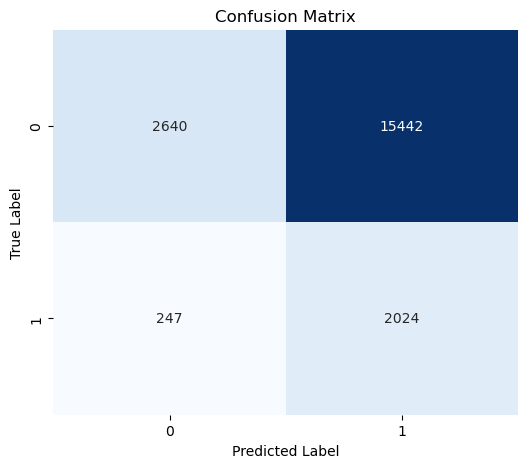

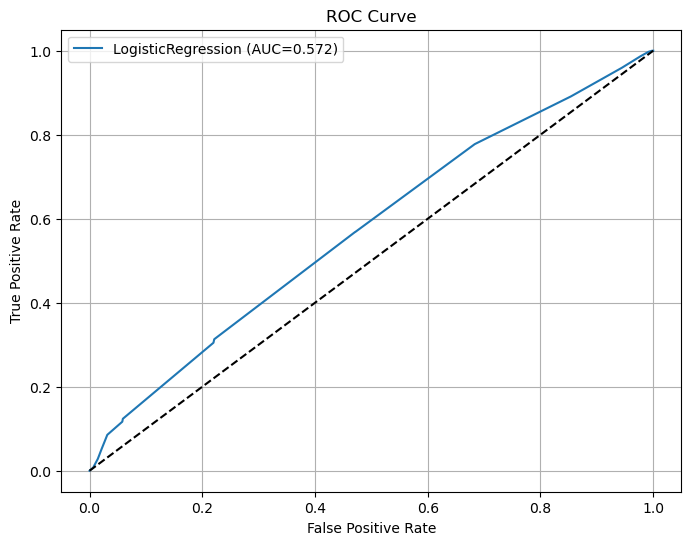

In [78]:
model1 = LogisticRegression(
    class_weight='balanced',  # увеличиваем вес класса 1
    C=0.001,
    max_iter=500,
    penalty='l1',
    solver='liblinear',
    random_state=42
)

rocaucconfmatr(model1, X5new_train, y_train_total_new[4], X5new_test, y5_test)

Для логистической регрессии с лучшим F1

----------------------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0      0.916     0.697     0.792     18082
           1      0.169     0.490     0.251      2271

    accuracy                          0.674     20353
   macro avg      0.542     0.594     0.522     20353
weighted avg      0.833     0.674     0.732     20353

----------------------------------------------------------------------
Confusion Matrix:
 [[12612  5470]
 [ 1158  1113]]
----------------------------------------------------------------------
ROC AUC: 0.6160254783348872
----------------------------------------------------------------------


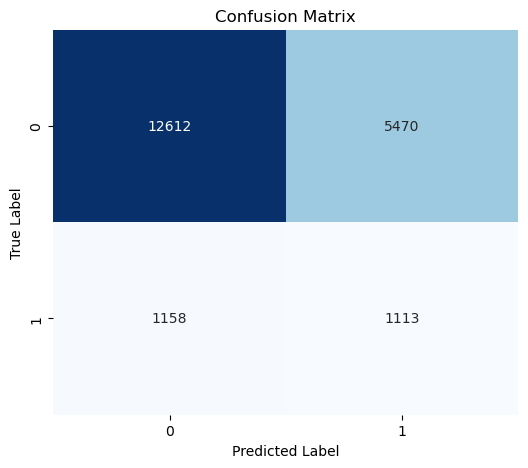

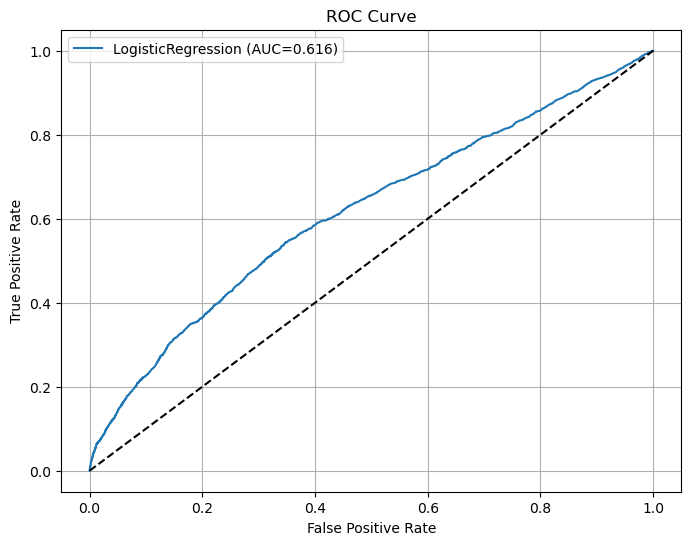

In [79]:
model2 = LogisticRegression(
    class_weight='balanced',  # увеличиваем вес класса 1
    C=0.001,
    max_iter=500,
    penalty='l1',
    solver='liblinear',
    random_state=42
)

rocaucconfmatr(model2, X2_train, y2_train, X2_test, y2_test)

Дерево решений с лучшим recall

----------------------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0      0.915     0.361     0.517     18082
           1      0.126     0.733     0.215      2271

    accuracy                          0.402     20353
   macro avg      0.520     0.547     0.366     20353
weighted avg      0.827     0.402     0.484     20353

----------------------------------------------------------------------
Confusion Matrix:
 [[ 6520 11562]
 [  606  1665]]
----------------------------------------------------------------------
ROC AUC: 0.5679349532057372
----------------------------------------------------------------------


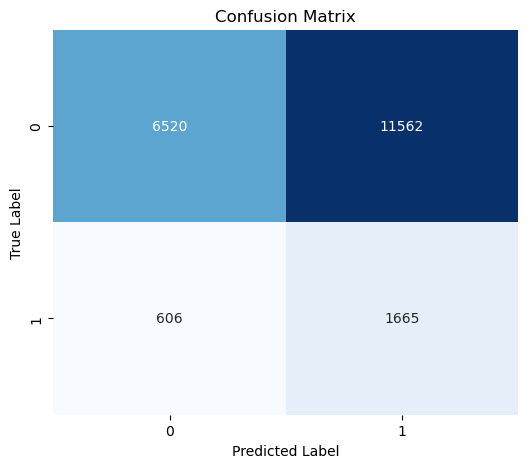

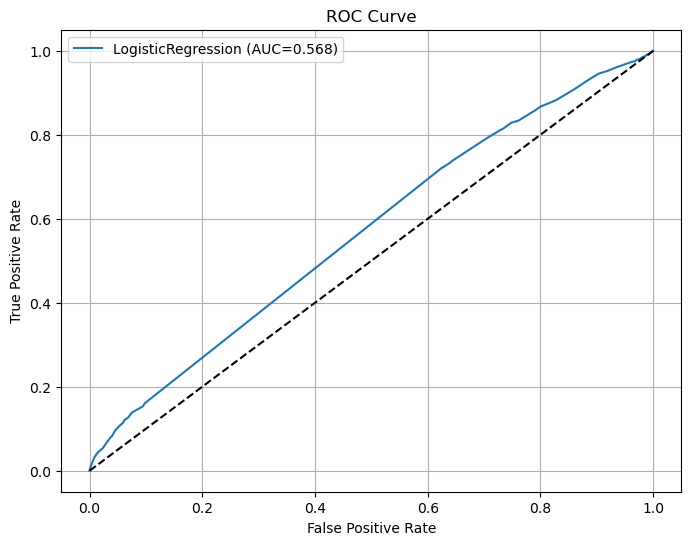

In [80]:
tree1 = DecisionTreeClassifier(criterion =  'gini',
    max_depth = 20,
    max_features = 'sqrt',
    max_leaf_nodes = 100,
    min_samples_leaf = 4,
    min_samples_split = 2,
    random_state=42,
    class_weight='balanced')

rocaucconfmatr(tree1, X1new_train, y_train_total_new[0], X1new_test, y1_test)

Дерево решений с лучшим F1

----------------------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0      0.917     0.666     0.772     18082
           1      0.164     0.522     0.249      2271

    accuracy                          0.650     20353
   macro avg      0.541     0.594     0.511     20353
weighted avg      0.833     0.650     0.713     20353

----------------------------------------------------------------------
Confusion Matrix:
 [[12039  6043]
 [ 1086  1185]]
----------------------------------------------------------------------
ROC AUC: 0.6177143085774278
----------------------------------------------------------------------


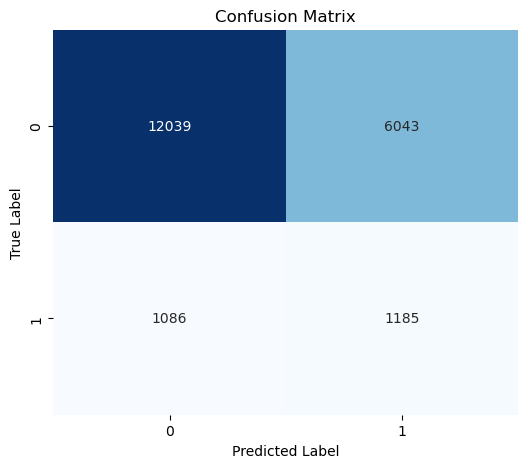

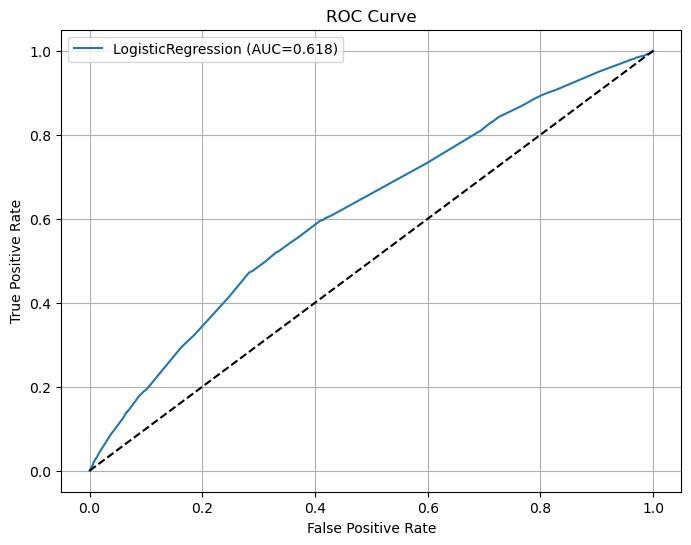

In [81]:
tree2 = DecisionTreeClassifier(criterion =  'gini',
    max_depth = 20,
    max_features = 'sqrt',
    max_leaf_nodes = 100,
    min_samples_leaf = 4,
    min_samples_split = 2,
    random_state=42,
    class_weight='balanced')

rocaucconfmatr(tree2, X5_train, y5_train, X5_test, y5_test)

Случайный лес с лучшим recall

----------------------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0      0.923     0.678     0.782     18082
           1      0.177     0.553     0.268      2271

    accuracy                          0.664     20353
   macro avg      0.550     0.615     0.525     20353
weighted avg      0.840     0.664     0.725     20353

----------------------------------------------------------------------
Confusion Matrix:
 [[12259  5823]
 [ 1016  1255]]
----------------------------------------------------------------------
ROC AUC: 0.6574355164941394
----------------------------------------------------------------------


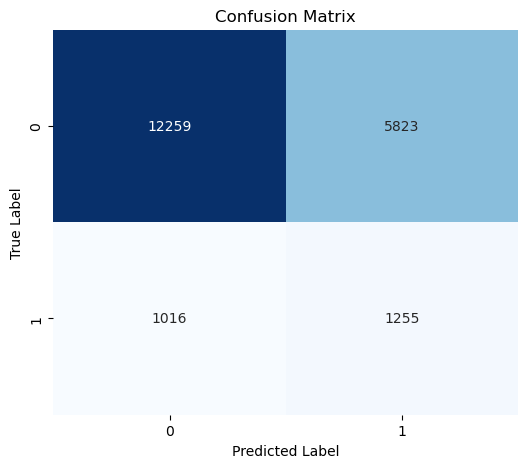

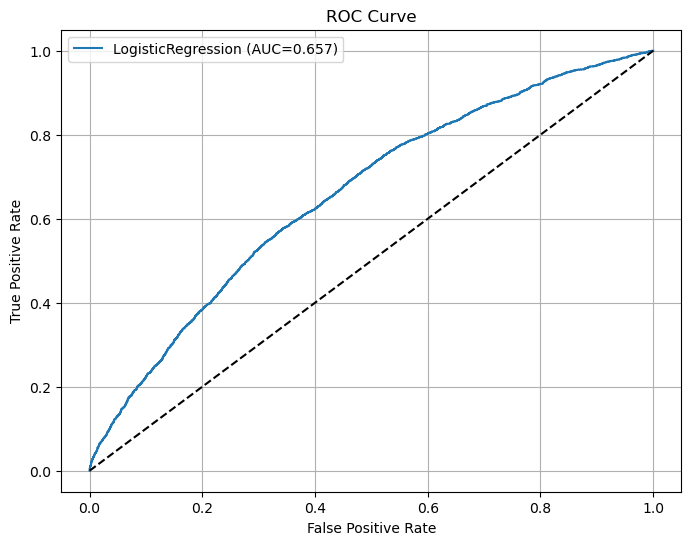

In [82]:
rf1 = RandomForestClassifier(
    class_weight= 'balanced_subsample',
    max_depth = 10,
    max_features = 'log2',
    min_samples_leaf = 4,
    min_samples_split = 10,
    n_estimators = 100,
    random_state=42)

rocaucconfmatr(rf1, X3_train, y3_train, X3_test, y3_test)

Случайный лес с лучшим F1

----------------------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0      0.922     0.709     0.801     18082
           1      0.183     0.519     0.271      2271

    accuracy                          0.688     20353
   macro avg      0.552     0.614     0.536     20353
weighted avg      0.839     0.688     0.742     20353

----------------------------------------------------------------------
Confusion Matrix:
 [[12821  5261]
 [ 1092  1179]]
----------------------------------------------------------------------
ROC AUC: 0.6609392112676579
----------------------------------------------------------------------


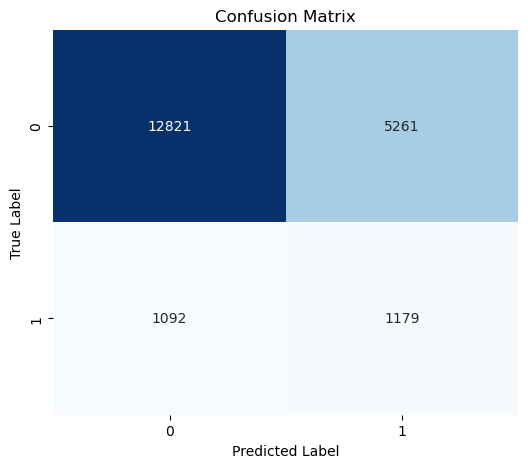

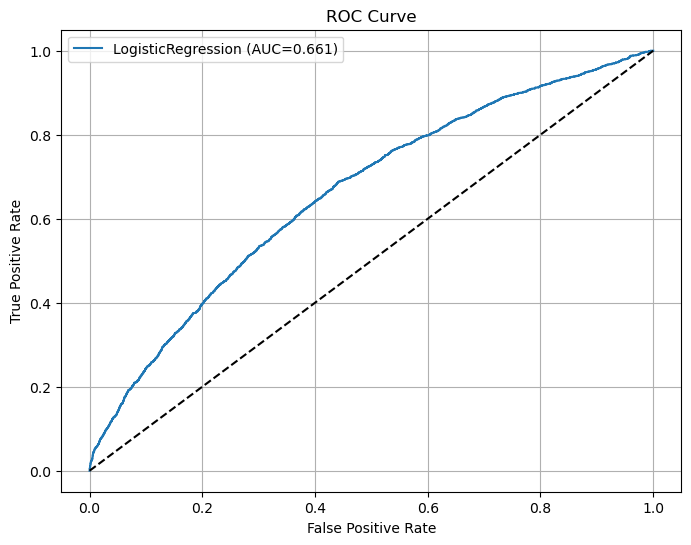

In [83]:
rf2 = RandomForestClassifier(
    class_weight= 'balanced_subsample',
    max_depth = 10,
    max_features = 'sqrt',
    min_samples_leaf = 4,
    min_samples_split = 2,
    n_estimators = 25,
    random_state=42)

rocaucconfmatr(rf2, X5_train, y5_train, X5_test, y5_test)

### 3.5. Ответы на вопросы:

### Вопрос 1: сравнение результатов моделей(метрик)
1. Модели с семплингом показывали хорошие метрики на обучающей выборке, но намного хуже на тестовой. Без семплинга эти значения в большинстве случаев похожи.  
  
2. Лучшие датасеты были под номерами: для регрессии - Х252 и Х22, для дерева - Х212 и Х25, для леса - Х25 и Х23. Внимание все выбранные модели без семплинга(Примечание Х1-Х5: основные модели с семплингом, Х12-Х52: с урезанным датасетом с семплингом, Х21-Х25: основные без семпплинга, Х212-Х252: с урезанным датасетом без семплинга)
    * Х22 - одна из основных моделей без семплинга. Все основные признаки с агрегацией, но без бинарных индикаторов.
    * Х23 - одна из основных моделей без семплинга. Немного урезанные основные признаки с агрегацией, но без бинарных индикаторов.
    * Х25 - одна из основных моделей без семплинга. Все основные признаки + флаги значимых болезней + бинарные индикаторы(время, визиты, лекарства) + взаимодействие между признаками.
    * Х212 - урезанная модель X21 без семплинга. БЕЗ большинства основных признаков. С агрегацией, но без бинарных индикаторов.
    * Х252 - урезанная модель X25 без семплинга. БЕЗ большинства основных признаков, флаги значимых болезней + бинарные индикаторы(время, визиты, лекарства) + взаимодействие между признаками.
  
3. Лучший ROC-AUC = 0.66 у случайного леса с Х25, лучший F1 = 0.27 для 1 класса у случайного леса с Х25, лучший recall = 0.891 у логистической регрессии с Х252.
  
4. Таким образом можно выделить модель случайного леса с Х25, где ROC-AUC почти умеренно хороший. Если же нам важно максимальное угадвание первого класса, то тогда лучше всего логистическая регрессия с Х252.

5. Можно сделать вывод, что создание флагов, бинарных индикаторов и взаимодействия между признаками сыграло главную роль в моделе.


### Вопрос 2: повышение точности предсказаний
1. Поскольку инженерия признаков является основной, и модели с созданными флагами и бинарными индикаторами показали себя лучше всего, то нужно проделать более глубокую инженерию признаков, создать индикаторы и флаги, которые содержат максимальное количество информации со всех основных столбцов.
2. Использовать улучшенные модели для дисбалансных классов, например Balanced Random Forest, XGBoost, LightGBM, CatBoost.
3. Подобрать более подходящий семплинг.

## Задание 4. Интерпретация лучшей модели

### 4.1. Построение summary plot, feature importance 

In [92]:
importances = rf2.feature_importances_
feat_imp = pd.Series(importances, index=X5.columns).sort_values(ascending=False)
print('Первые 10 важных предикторов:')
print(feat_imp[:10])

Первые 10 важных предикторов:
age_num_inpatient           0.275475
long_total_visits           0.087778
discharge_disposition_id    0.068353
age                         0.047344
longstay_procedures         0.029729
payer_code                  0.025697
admission_type_id           0.019949
admission_source_id         0.019753
diabetesMed                 0.016250
A1Cresult                   0.014562
dtype: float64


C:\Users\Anastasiia\AppData\Local\Temp\ipykernel_11244\817764566.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, plot_type="bar")


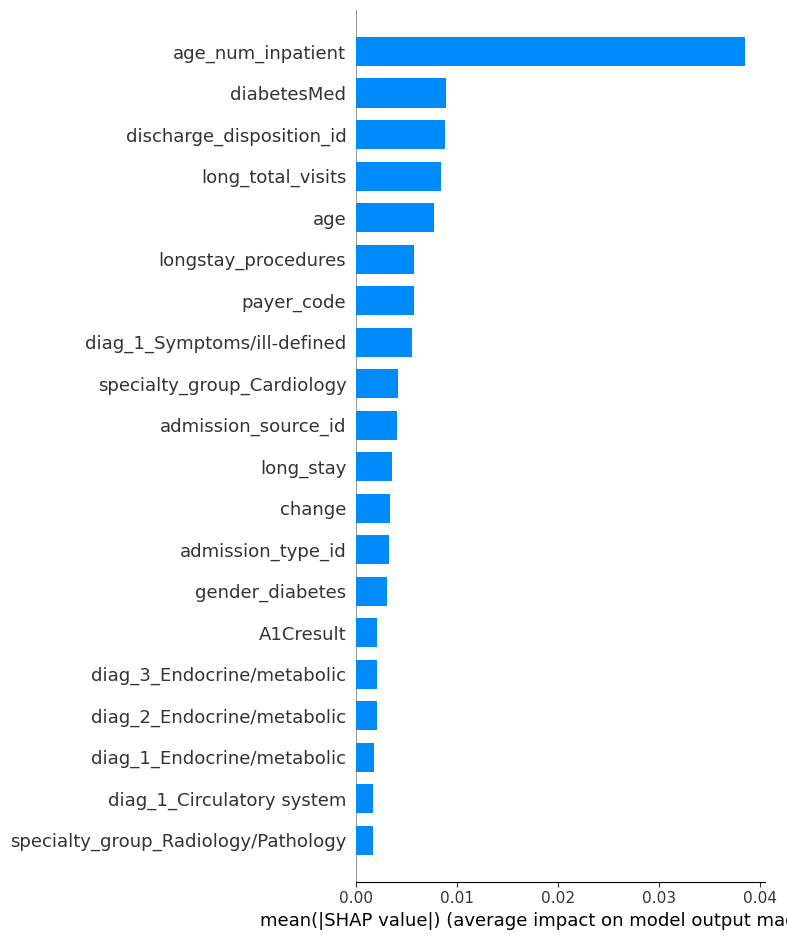

In [90]:
X_background = X5_test.sample(100, random_state=42)

X_explain = X5_test.sample(20, random_state=10) 

feature_names = X_explain.columns.tolist()

def predict_fn(X):
    X_df = pd.DataFrame(X, columns=feature_names)
    return rf2.predict_proba(X_df)[:, 1]

explainer = shap.Explainer(
    predict_fn, 
    X_background, 
    algorithm="permutation"
)

shap_values = explainer(X_explain)

shap.summary_plot(shap_values, X_explain, plot_type="bar")

#### 4.2. Анализ 10 ключевых признаков

1. age_num_inpatient — 0.275: частые госпитализации напрямую показывают серьёзное хроническое состояние или слабое здоровье.
2. long_total_visits — 0.088: пациенты с большим количеством визитов вероятнее всего обладают слабым здоровьем.
3. discharge_disposition_id — 0.068: способ выписки отражает состояние пациента после лечения.
4. age — 0.047: пожилые пациенты слабее восстанавливаются.
5. longstay_procedures — 0.030: показывает интенсивность и сложность лечения.
6. payer_code — 0.026: отражает доступность медицинских услуг.
7. admission_type_id — 0.020: экстренные госпитализации часто связаны с острыми состояниями.
8. admission_source_id — 0.020: отражает историю обращения и срочность.
9. diabetesMed — 0.016: диабет влияет на заживление и осложнения.
10. A1Cresult — 0.015: HbA1c (гликозилированный гемоглобин) показывает контроль диабета у пациента.

### 4.3. Ответы на вопросы:

#### Вопрос 1: Какие решения может принять врач, зная важные предикторы?

1. Ввести более частый мониторинг пациентов с высокой частотой госпитализаций.
2. Назначить контроль хронических заболеваний, например, диабета — оптимизация терапии, обучение пациента.
3. Планировать домашний уход или дистанционную помощь при мелких вопросах, чтобы уменьшить визиты в клинику.
4. Для пожилых пациентов предусмотреть профилактические меры.
5. Определить пациентов с ограниченным доступом к медуслугам и предложить программы поддержки.
6. Корректировка терапии и частоты наблюдений в зависимости от риска.
7. Информировать о важности соблюдения режима, питания, лекарств. (более подробно объяснять, если человек не соблюдает предписания)

### Бонусное задание 5. Оценка стоимости ошибки модели

In [135]:
FP = 1000
FN = 10000

In [ ]:
minsum = [100000000000000000000]
def confmatr(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # вероятности для класса 1

    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Ложноположительный прогноз модель ошибочно предсказывает госпитализацию, но пациент не возвращается в клинику) стоимость = 1000")
    print("Ложноотрицательный прогноз (модель не предсказала госпитализацию, но пациент вернулся в клинику) стоимость = 10000\n")
    print("Ложноположительный прогноз кол-во: ", conf_matrix[0][1])
    print("Ложноотрицательный прогноз кол-во: ", conf_matrix[1][0])
    print('-'*70)
    print("Ложноположительный прогноз cтоимость: ", conf_matrix[0][1]*FP)
    print("Ложноотрицательный прогноз стоимость: ", conf_matrix[1][0]*FN)
    print("Общая стоимость: ", conf_matrix[1][0]*FN + conf_matrix[0][1]*FP)
    if minsum[0] > conf_matrix[1][0]*FN + conf_matrix[0][1]*FP:
        minsum[0] = conf_matrix[1][0]*FN + conf_matrix[0][1]*FP
    plt.figure(figsize=(6,5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

Стоимость ошибок для случайного леса с лучшим recall

Ложноположительный прогноз модель ошибочно предсказывает госпитализацию, но пациент не возвращается в клинику) стоимость = 1000
Ложноотрицательный прогноз (модель не предсказала госпитализацию, но пациент вернулся в клинику) стоимость = 10000

Ложноположительный прогноз кол-во:  15442
Ложноотрицательный прогноз кол-во:  247
----------------------------------------------------------------------
Ложноположительный прогноз cтоимость:  15442000
Ложноотрицательный прогноз стоимость:  2470000
Общая стоимость:  17912000


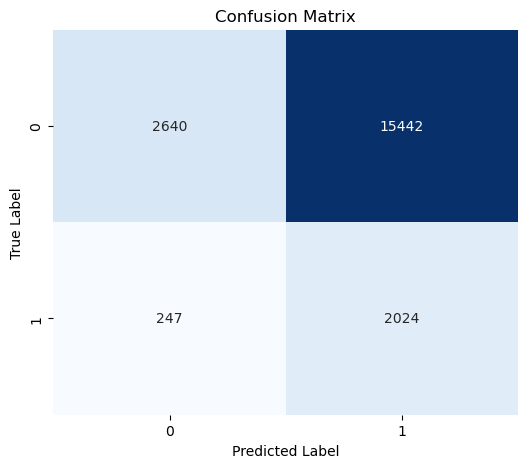

In [126]:
confmatr(model1, X5new_train, y_train_total_new[4], X5new_test, y5_test)

Стоимость ошибок для случайного леса с лучшим F1

Ложноположительный прогноз модель ошибочно предсказывает госпитализацию, но пациент не возвращается в клинику) стоимость = 1000
Ложноотрицательный прогноз (модель не предсказала госпитализацию, но пациент вернулся в клинику) стоимость = 10000

Ложноположительный прогноз кол-во:  5261
Ложноотрицательный прогноз кол-во:  1092
----------------------------------------------------------------------
Ложноположительный прогноз cтоимость:  5261000
Ложноотрицательный прогноз стоимость:  10920000
Общая стоимость:  16181000


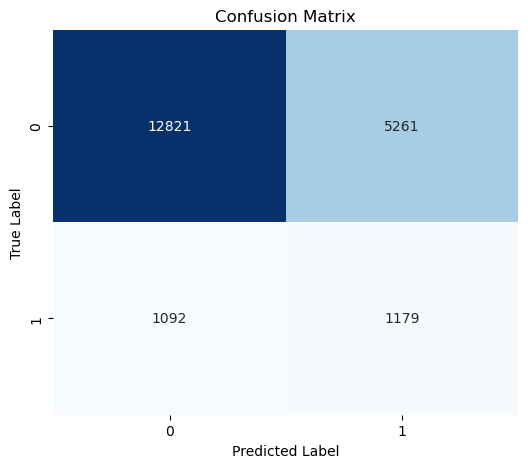

In [127]:
confmatr(rf2, X5_train, y5_train, X5_test, y5_test)

Дерево решений с лучшим recall

Ложноположительный прогноз модель ошибочно предсказывает госпитализацию, но пациент не возвращается в клинику) стоимость = 1000
Ложноотрицательный прогноз (модель не предсказала госпитализацию, но пациент вернулся в клинику) стоимость = 10000

Ложноположительный прогноз кол-во:  11562
Ложноотрицательный прогноз кол-во:  606
----------------------------------------------------------------------
Ложноположительный прогноз cтоимость:  11562000
Ложноотрицательный прогноз стоимость:  6060000
Общая стоимость:  17622000


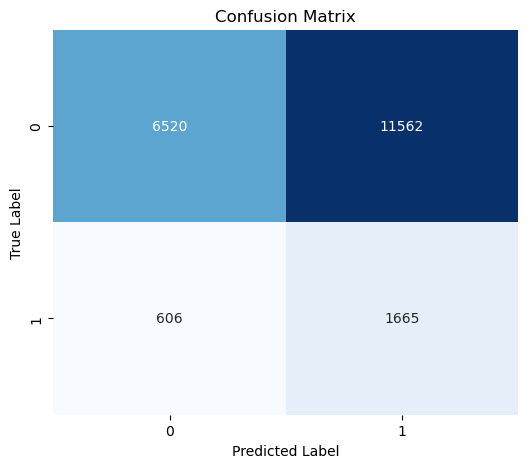

In [128]:
confmatr(tree1, X1new_train, y_train_total_new[0], X1new_test, y1_test)

Дерево решений с лучшим F1

Ложноположительный прогноз модель ошибочно предсказывает госпитализацию, но пациент не возвращается в клинику) стоимость = 1000
Ложноотрицательный прогноз (модель не предсказала госпитализацию, но пациент вернулся в клинику) стоимость = 10000

Ложноположительный прогноз кол-во:  6043
Ложноотрицательный прогноз кол-во:  1086
----------------------------------------------------------------------
Ложноположительный прогноз cтоимость:  6043000
Ложноотрицательный прогноз стоимость:  10860000
Общая стоимость:  16903000


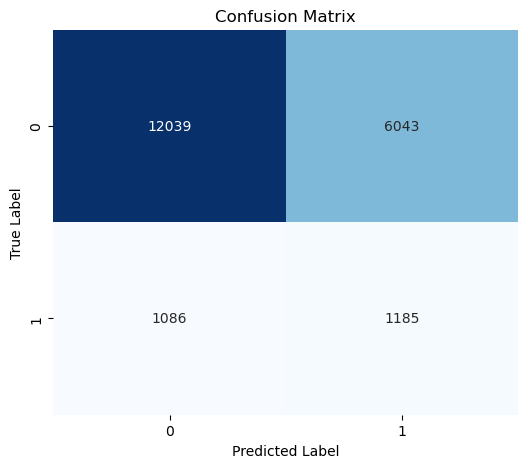

In [129]:
confmatr(tree2, X5_train, y5_train, X5_test, y5_test)

Для логистической регрессии с лучшим recall

Ложноположительный прогноз модель ошибочно предсказывает госпитализацию, но пациент не возвращается в клинику) стоимость = 1000
Ложноотрицательный прогноз (модель не предсказала госпитализацию, но пациент вернулся в клинику) стоимость = 10000

Ложноположительный прогноз кол-во:  15442
Ложноотрицательный прогноз кол-во:  247
----------------------------------------------------------------------
Ложноположительный прогноз cтоимость:  15442000
Ложноотрицательный прогноз стоимость:  2470000
Общая стоимость:  17912000


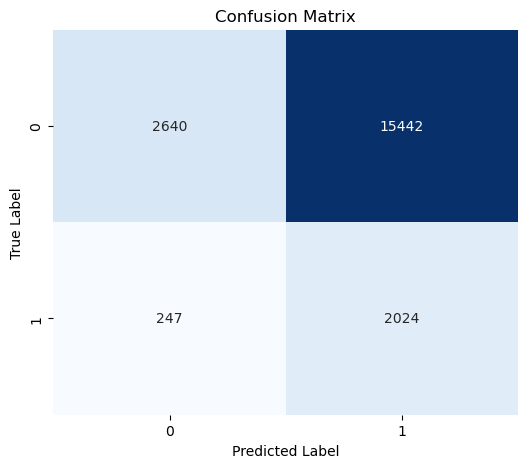

In [130]:
confmatr(model1, X5new_train, y_train_total_new[4], X5new_test, y5_test)

Для логистической регрессии с лучшим F1

Ложноположительный прогноз модель ошибочно предсказывает госпитализацию, но пациент не возвращается в клинику) стоимость = 1000
Ложноотрицательный прогноз (модель не предсказала госпитализацию, но пациент вернулся в клинику) стоимость = 10000

Ложноположительный прогноз кол-во:  5470
Ложноотрицательный прогноз кол-во:  1158
----------------------------------------------------------------------
Ложноположительный прогноз cтоимость:  5470000
Ложноотрицательный прогноз стоимость:  11580000
Общая стоимость:  17050000


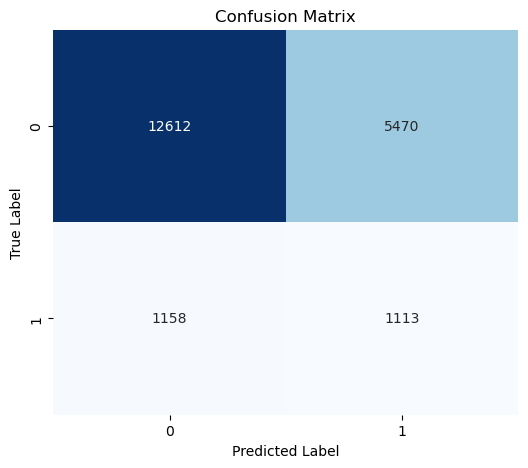

In [131]:
confmatr(model2, X2_train, y2_train, X2_test, y2_test)

In [134]:
print(minsum[0])

16181000


### Наиболее «выгодна» для клиники модель случайного леса с лучшим F1

Изменение порога вероятности

In [147]:
y_prob = rf2.predict_proba(X5_test)[:,1]
thresholds = np.linspace(0.1, 0.9, 50)

for t in thresholds:
    # Предсказание по порогу
    y_pred_thresh = (y_prob >= t).astype(int)
    
    # Матрица ошибок
    tn, fp, fn, tp = confusion_matrix(y5_test, y_pred_thresh).ravel()
    
    total_cost = fp*FP + fn*FN
    
    print(f"Порог = {t:.2f}:  FP = {fp}, FN = {fn}, Total = {total_cost}")

Порог = 0.10:  FP = 18082, FN = 0, Total = 18082000
Порог = 0.12:  FP = 18081, FN = 0, Total = 18081000
Порог = 0.13:  FP = 18081, FN = 0, Total = 18081000
Порог = 0.15:  FP = 18081, FN = 0, Total = 18081000
Порог = 0.17:  FP = 18077, FN = 0, Total = 18077000
Порог = 0.18:  FP = 18071, FN = 0, Total = 18071000
Порог = 0.20:  FP = 18066, FN = 0, Total = 18066000
Порог = 0.21:  FP = 18060, FN = 0, Total = 18060000
Порог = 0.23:  FP = 18042, FN = 0, Total = 18042000
Порог = 0.25:  FP = 18027, FN = 0, Total = 18027000
Порог = 0.26:  FP = 18009, FN = 0, Total = 18009000
Порог = 0.28:  FP = 17992, FN = 1, Total = 18002000
Порог = 0.30:  FP = 17956, FN = 2, Total = 17976000
Порог = 0.31:  FP = 17911, FN = 6, Total = 17971000
Порог = 0.33:  FP = 17832, FN = 6, Total = 17892000
Порог = 0.34:  FP = 17664, FN = 15, Total = 17814000
Порог = 0.36:  FP = 17315, FN = 38, Total = 17695000
Порог = 0.38:  FP = 16749, FN = 72, Total = 17469000
Порог = 0.39:  FP = 15883, FN = 121, Total = 17093000
Порог =

Минимальные затраты в точке Порог = 0.46:  FP = 9166, FN = 604, Total = 15206000